#**Exploratory Data Analysis**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sys
import os
import logging
import warnings
warnings.filterwarnings("ignore")

In [ ]:
LOG_FILE = 'eda_task1.log'
logger = logging.getLogger('eda_task1')
logger.setLevel(logging.DEBUG)
logger.propagate = False

In [ ]:
if not logger.handlers:
    formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setLevel(logging.INFO)
    console_handler.setFormatter(formatter)
    file_handler = logging.FileHandler(LOG_FILE)
    file_handler.setLevel(logging.DEBUG)
    file_handler.setFormatter(formatter)
    logger.addHandler(console_handler)
    logger.addHandler(file_handler)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)
logger.info(f"Libraries imported, plotting style configured. Full detail is being written to {LOG_FILE}")

2026-09-08 14:08:39,642 - eda_task1 - INFO - Libraries imported, plotting style configured. Full detail is being written to eda_task1.log


In [ ]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 140
plt.rcParams["figure.figsize"] = (11, 5)

**Load the data**

In [ ]:
logger.info("DATA LOADED ")

logger.info("Loading store_train.csv and store_test.csv ...")#check if this line is needed
train = pd.read_csv(("store_train.csv"), low_memory=False)
test  = pd.read_csv(("store_test.csv"),  low_memory=False)

2026-09-08 14:08:39,667 - eda_task1 - INFO - DATA LOADED 
2026-09-08 14:08:39,671 - eda_task1 - INFO - Loading store_train.csv and store_test.csv ...


In [ ]:
train["Date"] = pd.to_datetime(train["Date"])
test["Date"]  = pd.to_datetime(test["Date"])

In [ ]:
logger.info(f"Train shape : {train.shape}")
logger.info(f"Test  shape : {test.shape}")
logger.info(f"Train date range : {train['Date'].min().date()} → {train['Date'].max().date()}")
logger.info(f"Test  date range : {test['Date'].min().date()} → {test['Date'].max().date()}")
logger.debug(f"store_train dtypes: {dict(train.dtypes.astype(str))}")
logger.info(f"Unique stores (train) : {train['Store'].nunique()}")
logger.info(f"Unique stores (test)  : {test['Store'].nunique()}")

2026-09-08 14:08:40,225 - eda_task1 - INFO - Train shape : (252322, 9)
2026-09-08 14:08:40,228 - eda_task1 - INFO - Test  shape : (41088, 18)
2026-09-08 14:08:40,238 - eda_task1 - INFO - Train date range : 2014-12-14 → 2015-07-31
2026-09-08 14:08:40,243 - eda_task1 - INFO - Test  date range : 2015-08-01 → 2015-09-17
2026-09-08 14:08:40,255 - eda_task1 - INFO - Unique stores (train) : 1115
2026-09-08 14:08:40,258 - eda_task1 - INFO - Unique stores (test)  : 856


In [ ]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555.0,1,1,0,1
1,2,5,2015-07-31,6064,625.0,1,1,0,1
2,3,5,2015-07-31,8314,821.0,1,1,0,1
3,4,5,2015-07-31,13995,1498.0,1,1,0,1
4,5,5,2015-07-31,4822,559.0,1,1,0,1


In [ ]:
test.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,CompetitionOpenSinceKnown
0,1,1,4,2015-09-17,1,1,0,0,c,a,1270.0,9,2008,0,0,0,NoPromo2,1
1,2,3,4,2015-09-17,1,1,0,0,a,a,14130.0,12,2006,1,14,2011,"Jan,Apr,Jul,Oct",1
2,3,7,4,2015-09-17,1,1,0,0,a,c,24000.0,4,2013,0,0,0,NoPromo2,1
3,4,8,4,2015-09-17,1,1,0,0,a,a,7520.0,10,2014,0,0,0,NoPromo2,1
4,5,9,4,2015-09-17,1,1,0,0,a,c,2030.0,8,2000,0,0,0,NoPromo2,1


In [ ]:
# Helper calendar features
for df in (train, test):
    df["Year"]       = df["Date"].dt.year
    df["Month"]      = df["Date"].dt.month
    df["Day"]        = df["Date"].dt.day
    df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["IsWeekend"]  = df["DayOfWeek"].isin([6, 7]).astype(int)
    df["IsStateHoliday"] = (df["StateHoliday"] != "0").astype(int)

In [ ]:
# Open-only view (most analyses on open stores)
open_train = train[train["Open"] == 1].copy()
logger.info(f"Open train rows : {len(open_train):,}")

2026-09-08 14:08:40,953 - eda_task1 - INFO - Open train rows : 208,272


* Open train rows: 208,272 → There are 208,272 records where the stores were open in the training dataset.
* These rows are the most relevant for analyzing sales, customers, promotions, and store performance.
* Closed-store records are excluded because their sales are generally zero and are not useful for sales-performance analysis.

In [ ]:
#To check
print("train shape:", train.shape)
print("Min date:", train['Date'].min())
print("Max date:", train['Date'].max())
print("Unique dates:", train['Date'].nunique())


train shape: (252322, 15)
Min date: 2014-12-14 00:00:00
Max date: 2015-07-31 00:00:00
Unique dates: 230


 Data Quality

In [ ]:
logger.info("\n" + "-" * 50)
logger.info("DATA QUALITY CHECKS")
logger.info("-" * 50)

def missing_summary(df, name):
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    if miss.empty:
        logger.info(f"{name}: NO missing values")
    else:
        logger.info(f"{name} missing:\n{miss}")

missing_summary(train, "Train")
missing_summary(test,  "Test")

logger.info(f"\nTrain Open==0 rows : {(train.Open==0).sum():,}")
logger.info(f"Train Sales==0 rows: {(train.Sales==0).sum():,}")

2026-09-08 14:08:41,033 - eda_task1 - INFO - 
--------------------------------------------------
2026-09-08 14:08:41,042 - eda_task1 - INFO - DATA QUALITY CHECKS
2026-09-08 14:08:41,043 - eda_task1 - INFO - --------------------------------------------------
2026-09-08 14:08:41,100 - eda_task1 - INFO - Train missing:
Customers       1
StateHoliday    1
dtype: int64
2026-09-08 14:08:41,146 - eda_task1 - INFO - Test: NO missing values
2026-09-08 14:08:41,151 - eda_task1 - INFO - 
Train Open==0 rows : 44,050
2026-09-08 14:08:41,161 - eda_task1 - INFO - Train Sales==0 rows: 44,053


* Train missing values: Only Customers and StateHoliday have 1 missing value each; the remaining columns are complete.
* Test data: There are no missing values, indicating the test dataset is complete.
* Closed stores: 44,050 training records have Open = 0.
* Zero sales: 44,053 records have Sales = 0, which is slightly higher than the number of closed-store records.
* This indicates that 3 open-store records also have zero sales, which were previously identified as unusual cases.

In [ ]:
store_df = pd.read_csv("cleaned_store.csv")


In [ ]:
open_train = open_train.merge(
    store_df[["Store", "CompetitionDistance"]],
    on="Store",
    how="left"
)


In [ ]:
desc = open_train[["Sales", "Customers", "CompetitionDistance"]].describe().T
logger.info(f"\nNumeric summary (Open stores):\n{desc.round(1)}")

2026-09-08 14:08:41,485 - eda_task1 - INFO - 
Numeric summary (Open stores):
                        count    mean     std   min     25%     50%     75%  \
Sales                208272.0  7205.7  3162.0   0.0  5070.0  6603.0  8641.0   
Customers            208272.0   762.5   397.1   0.0   523.0   677.0   890.0   
CompetitionDistance  208272.0  5432.8  7762.9  20.0   720.0  2325.0  6880.0   

                         max  
Sales                41551.0  
Customers             5458.0  
CompetitionDistance  75860.0  


* Sales: Average sales are about 7,206, with a maximum of 41,551, showing considerable variation across open stores.
* Customers: Open stores have an average of about 763 customers, with a maximum of 5,458.
* Competition Distance: The average distance is about 5.43 km, while the median is 2.33 km, indicating some stores have competitors much farther away.
* Overall, the data shows substantial variation in sales, customer numbers, and competition distance among open stores.

**UNIVARIATE ANALYSIS**

2026-09-08 14:08:45,964 - eda_task1 - INFO - Sales skewness : 1.544
2026-09-08 14:08:45,982 - eda_task1 - INFO - Sales kurtosis : 4.529


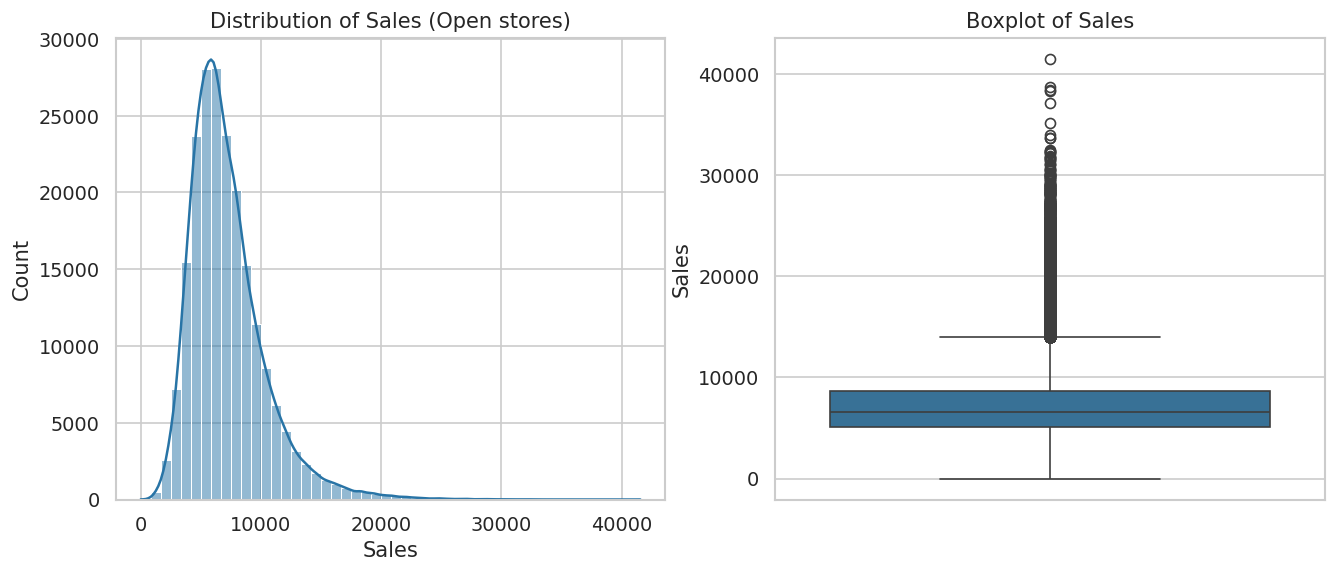

In [ ]:
# Target: Sales
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(open_train["Sales"], bins=50, kde=True, ax=axes[0], color="#2874A6")
axes[0].set_title("Distribution of Sales (Open stores)")
axes[0].set_xlabel("Sales")

sns.boxplot(y=open_train["Sales"], ax=axes[1], color="#2874A6")
axes[1].set_title("Boxplot of Sales")

logger.info(f"Sales skewness : {open_train['Sales'].skew():.3f}")
logger.info(f"Sales kurtosis : {open_train['Sales'].kurtosis():.3f}")

* Sales skewness = 1.544 - Sales distribution is positively/right-skewed, with a longer tail toward higher sales values.
* Kurtosis = 4.529 - The distribution is more heavy-tailed than a normal distribution, indicating more extreme values.
* The boxplot confirms many high-sales outliers, extending above approximately 14,000.
* Overall, most stores have sales concentrated around the 5,000-10,000 range, while a smaller number of stores record very high sales.
* These high values are likely genuine business observations rather than errors, so they should be investigated rather than automatically removed.

Text(0.5, 1.0, 'Boxplot of Customers')

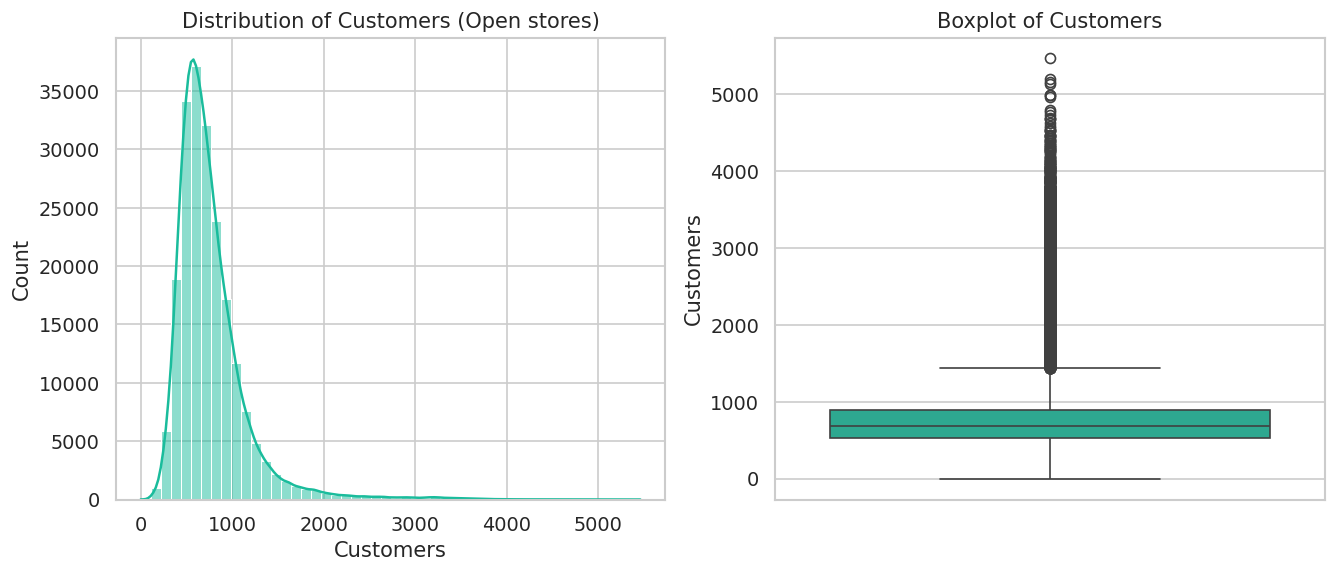

In [ ]:
# Customers
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(open_train["Customers"], bins=50, kde=True, ax=axes[0], color="#1ABC9C")
axes[0].set_title("Distribution of Customers (Open stores)")
sns.boxplot(y=open_train["Customers"], ax=axes[1], color="#1ABC9C")
axes[1].set_title("Boxplot of Customers")

* The customer distribution is right-skewed, with most observations concentrated around 500-1,000 customers.
* The boxplot shows a large number of high-customer outliers, extending up to about 5,500 customers.
* Most stores have relatively moderate customer counts, while a smaller number attract very high customer traffic.
* These extreme values may represent busy stores, promotions, or special days

Text(0.5, 1.0, 'log1p(CompetitionDistance)')

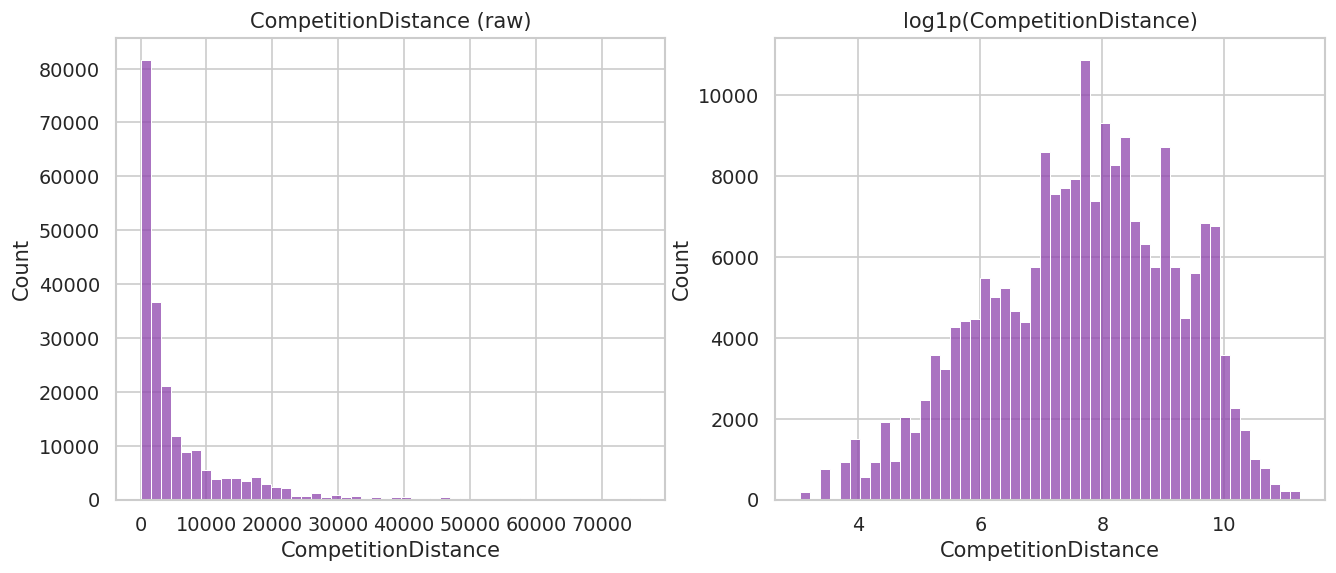

In [ ]:
# CompetitionDistance
comp = open_train["CompetitionDistance"].dropna()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(comp, bins=50, ax=axes[0], color="#8E44AD")
axes[0].set_title("CompetitionDistance (raw)")
sns.histplot(np.log1p(comp), bins=50, ax=axes[1], color="#8E44AD")
axes[1].set_title("log1p(CompetitionDistance)")

* Before transformation: The raw data is strongly right-skewed, with most stores having relatively short competition distances and a long tail of stores with very large distances.
* After log1p transformation: The distribution is considerably less skewed and more evenly spread, with most values falling roughly between 6 and 10 on the transformed scale.
* The log transformation reduces the influence of extreme distances and produces a more stable distribution, which can improve the performance of many statistical and machine-learning models.

In [ ]:
train = train.merge(
    store_df[
        [
            "Store",
            "StoreType",
            "Assortment",
            "Promo2"
        ]
    ],
    on="Store",
    how="left"
)


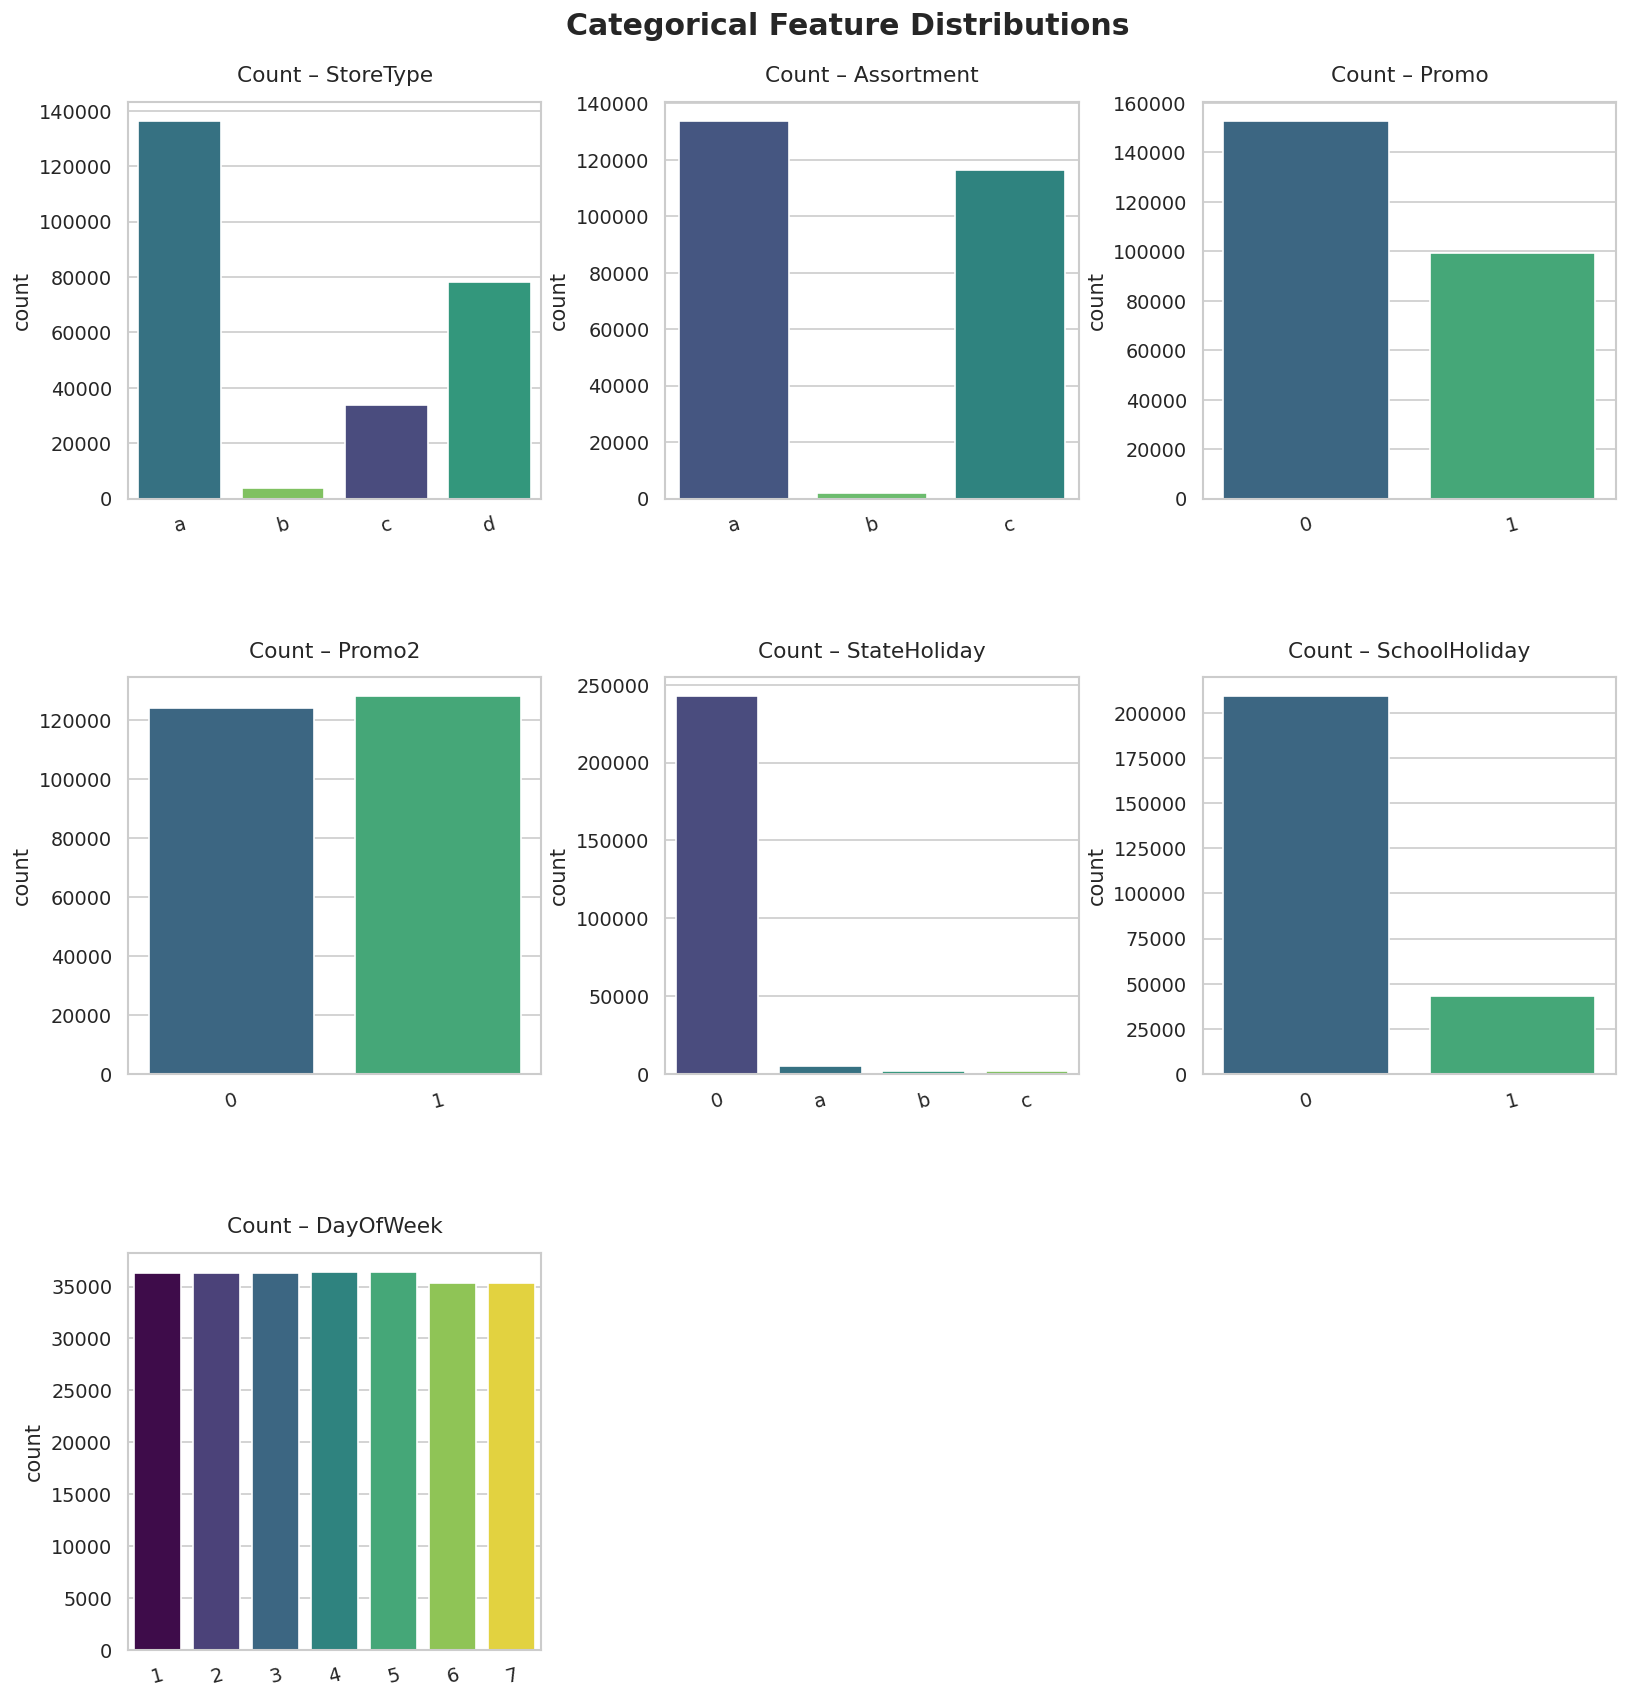

In [ ]:
# Categorical features
cat_cols = ["StoreType", "Assortment", "Promo","Promo2", "StateHoliday", "SchoolHoliday", "DayOfWeek"]

fig, axes = plt.subplots(3, 3, figsize=(16, 15))
axes = axes.ravel()
for i, col in enumerate(cat_cols):
    order = sorted(train[col].unique()) if col != "StateHoliday" else ["0", "a", "b", "c"]

    sns.countplot(
        data=train,
        x=col,
        order=order,
        ax=axes[i],
        hue=col,
        palette="viridis",
        legend=False
    )

    axes[i].set_title(f"Count – {col}", fontsize=13, pad=12)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=15)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.subplots_adjust(hspace=0.45,
    wspace=0.30,
    top=0.93,
    bottom=0.07)

plt.suptitle("Categorical Feature Distributions",
    fontsize=18,
    fontweight="bold")
plt.show()

* StoreType: Type a is the most common, followed by d and c, while b has very few stores.
Assortment: Type a is the most frequent, c is also common, while b is rare.
* Promo: Most records have Promo = 0, meaning promotions were not active on most days.
Promo2: The data is fairly balanced, with slightly more records having Promo2 = 1.
* StateHoliday: Most observations have no state holiday (0); holiday categories are much less frequent.
* SchoolHoliday: Most days are not school holidays (0), while a smaller portion are school holidays.
* DayOfWeek: The observations are almost evenly distributed across all seven days, with only small differences in counts.
* The dataset has some strong class imbalances in features such as StoreType, StateHoliday, Promo, and SchoolHoliday, while DayOfWeek is well balanced.

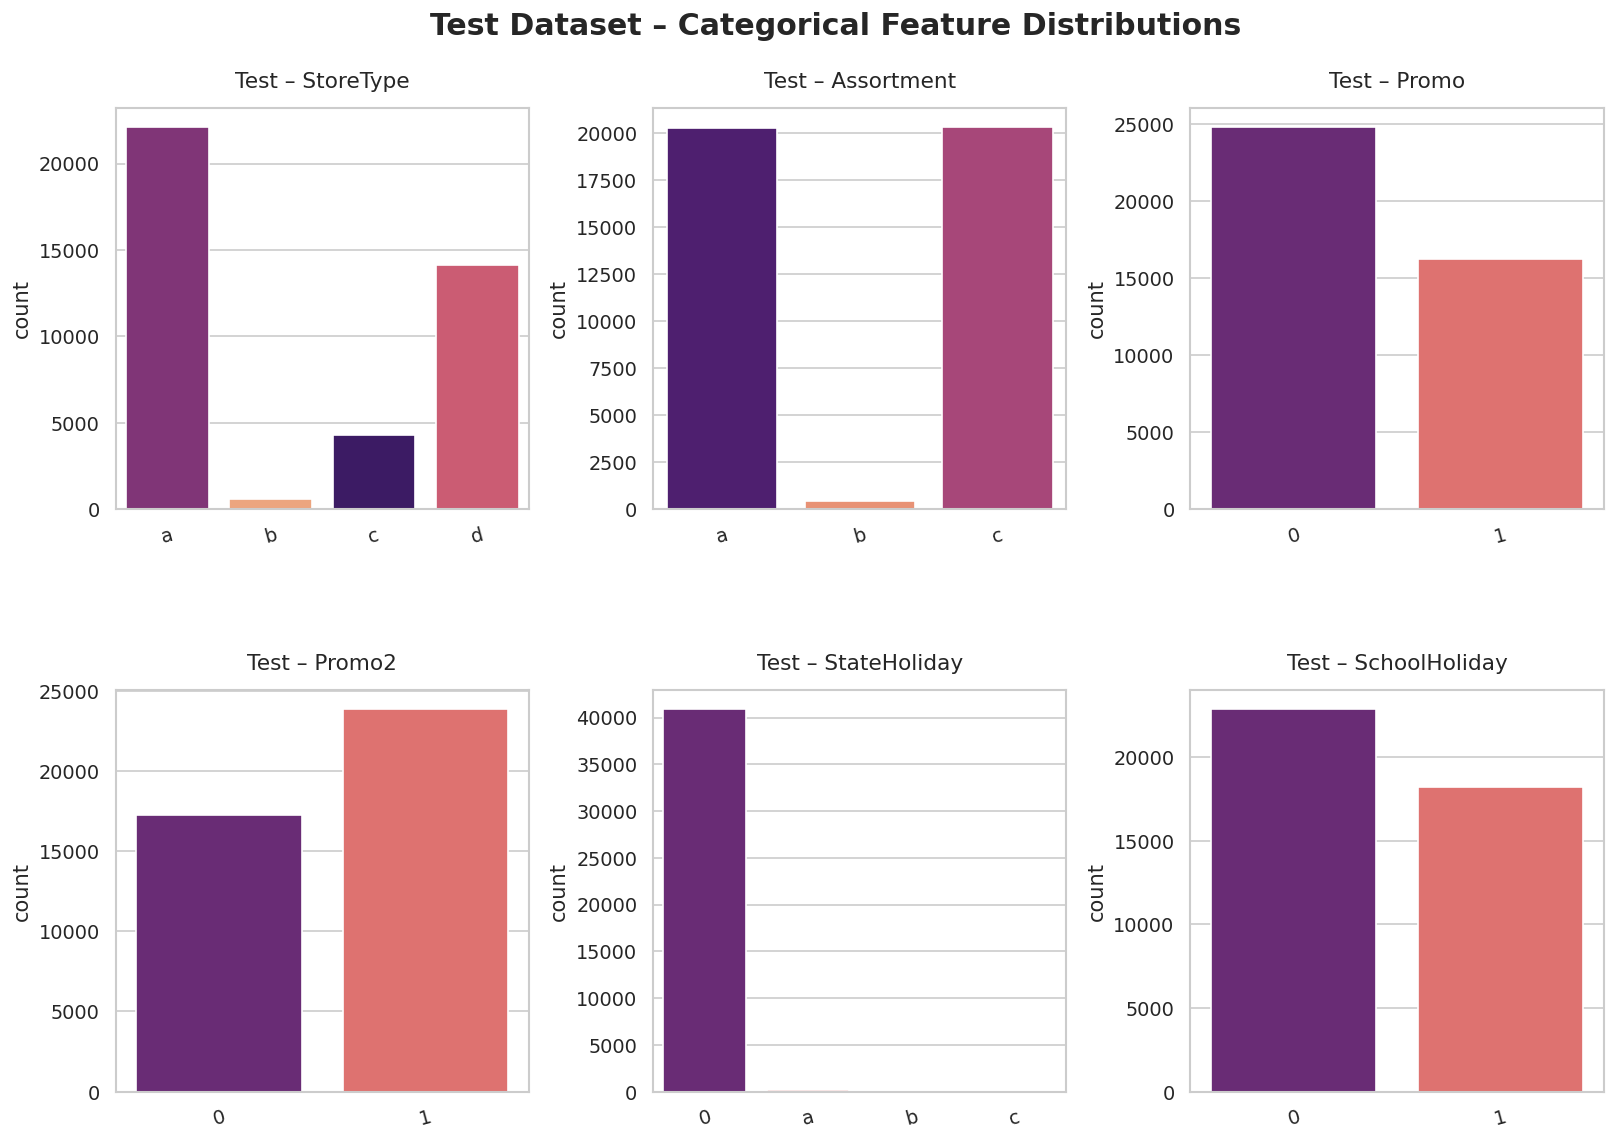

2026-09-08 14:09:00,577 - eda_task1 - INFO - Univariate analysis completed.


In [ ]:
# Same for test (feature comparison later)

test_cat_cols = [
    "StoreType",
    "Assortment",
    "Promo",
    "Promo2",
    "StateHoliday",
    "SchoolHoliday"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()
for i, col in enumerate(test_cat_cols):
    order = (
        sorted(test[col].unique())
        if col != "StateHoliday"
        else ["0", "a", "b", "c"]
    )

    sns.countplot(
        data=test,
        x=col,
        order=order,
        ax=axes[i],
        hue=col,
        palette="magma",
        legend=False)

    axes[i].set_title(
        f"Test – {col}",
        fontsize=13,
        pad=12 )

    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=15)

plt.subplots_adjust(
    hspace=0.45,
    wspace=0.30,
    top=0.90,
    bottom=0.08)

plt.suptitle(
    "Test Dataset – Categorical Feature Distributions",
    fontsize=18,
    fontweight="bold")

plt.show()
logger.info("Univariate analysis completed.")

* StoreType: Type a is the most common, followed by d and c. Type b has very few observations.
Assortment: Types a and c are almost equally represented, while type b is rare.
* Promo: Most observations have Promo = 0, meaning promotions are not active on most days.
* Promo2: Promo2 = 1 is more common than 0, indicating that many stores participate in the continuing promotion program.
* StateHoliday: The vast majority of observations have no state holiday (0); the other categories occur very rarely.
* SchoolHoliday: Most observations are not school holidays (0), while a smaller portion have SchoolHoliday = 1.
* The test dataset has distributions similar to the training data, with noticeable imbalance in StoreType, Promo, StateHoliday, and SchoolHoliday, while Assortment is relatively balanced between types a and c.

BIVARIATE ANALYSIS

2026-09-08 14:09:00,655 - eda_task1 - INFO - Pearson r (Sales, Customers) = 0.8129


Text(0.5, 1.0, 'Sales vs Customers  | Pearson r = 0.813')

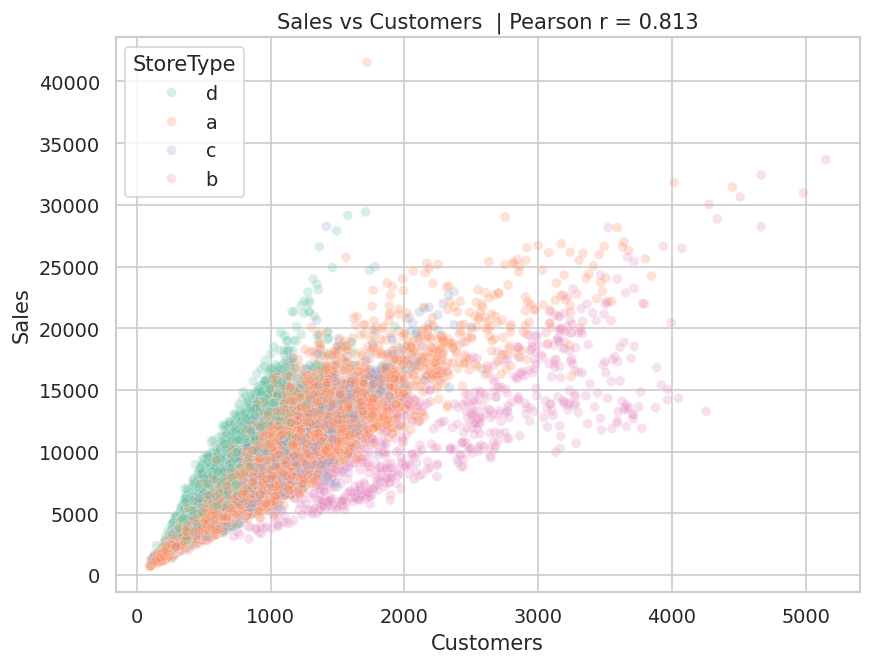

In [ ]:
#Sales vs Customers
open_train = open_train.merge(
    store_df[["Store", "StoreType"]],
    on="Store",
    how="left"
)

corr_sc = open_train[["Sales", "Customers"]].corr().iloc[0, 1]
logger.info(f"Pearson r (Sales, Customers) = {corr_sc:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
sample = open_train.sample(min(40000, len(open_train)), random_state=42)
sns.scatterplot(data=sample, x="Customers", y="Sales", hue="StoreType", palette= "Set2", alpha=0.25, s=35, ax=ax)
ax.set_title(f"Sales vs Customers  | Pearson r = {corr_sc:.3f}")


* The scatter plot shows a strong positive relationship between Customers and Sales.
* The Pearson correlation (r = 0.813) indicates that higher customer counts generally lead to higher sales.
* Sales increase as the number of customers increases across all store types.
* Store Type d and a show a wider range of customer and sales values.
* Some outliers are visible, with unusually high sales or customer counts.
* Overall, customer traffic is a major factor influencing Rossmann store sales.

2026-09-08 14:09:05,608 - eda_task1 - INFO - 
Mean Sales/Customers by Promo:
        Sales  Customers
Promo                   
0      6158.1      700.0
1      8427.3      835.4


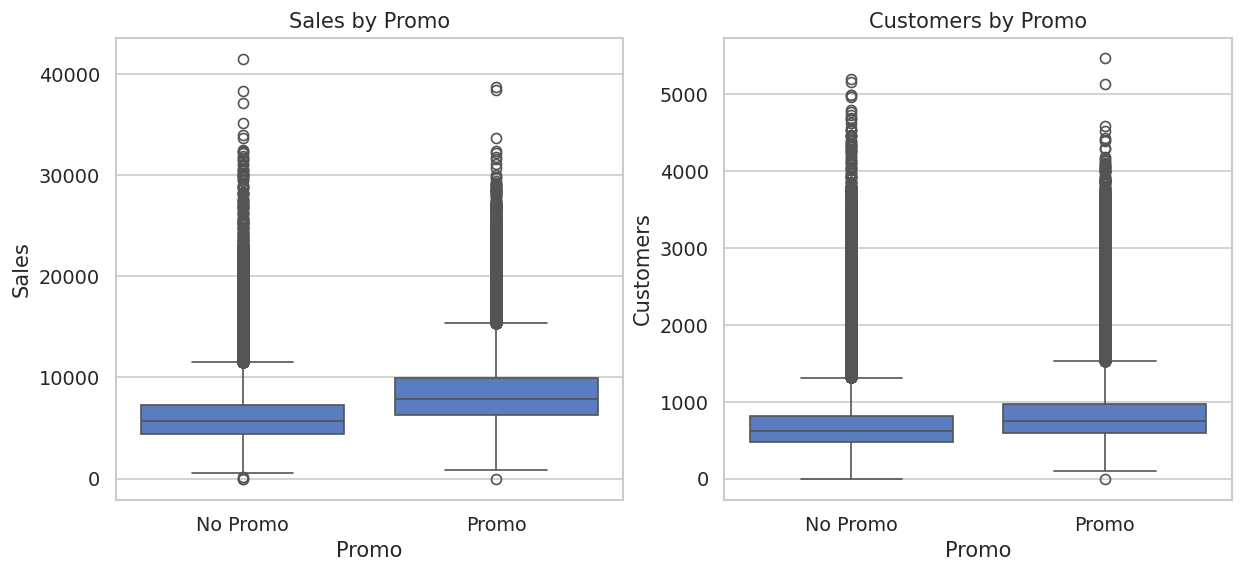

In [ ]:
# Sales vs Promo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=open_train, x="Promo", y="Sales", ax=axes[0])
axes[0].set_title("Sales by Promo")
axes[0].set_xticklabels(["No Promo", "Promo"])
sns.boxplot(data=open_train, x="Promo", y="Customers", ax=axes[1])
axes[1].set_title("Customers by Promo")
axes[1].set_xticklabels(["No Promo", "Promo"])

promo_means = open_train.groupby("Promo")[["Sales", "Customers"]].mean()
logger.info(f"\nMean Sales/Customers by Promo:\n{promo_means.round(1)}")

* Stores with Promotions generally have higher sales than stores without promotions.
* The median sales for Promo stores is noticeably higher than No Promo stores.
* Customers also tend to be higher during promotions, suggesting increased customer traffic.
* Both plots show several high-value outliers in sales and customer counts.
* The spread is larger for Promo stores, indicating greater variation in performance.
* Here the promotions appear to have a positive impact on both customer visits and sales.

In [ ]:
# Merge store-level information into the sales data
store_cols = [
    "Store",
    "StoreType",
    "Assortment",
    "CompetitionDistance",
    "Promo2",
    "PromoInterval"
]

train = train.merge(
    store_df[store_cols],
    on="Store",
    how="left"
)

# Keep only open stores
open_train = train[train["Open"] == 1].copy()


In [ ]:
open_train = open_train.rename(columns={
    "StoreType_x": "StoreType",
    "Assortment_x": "Assortment"
})


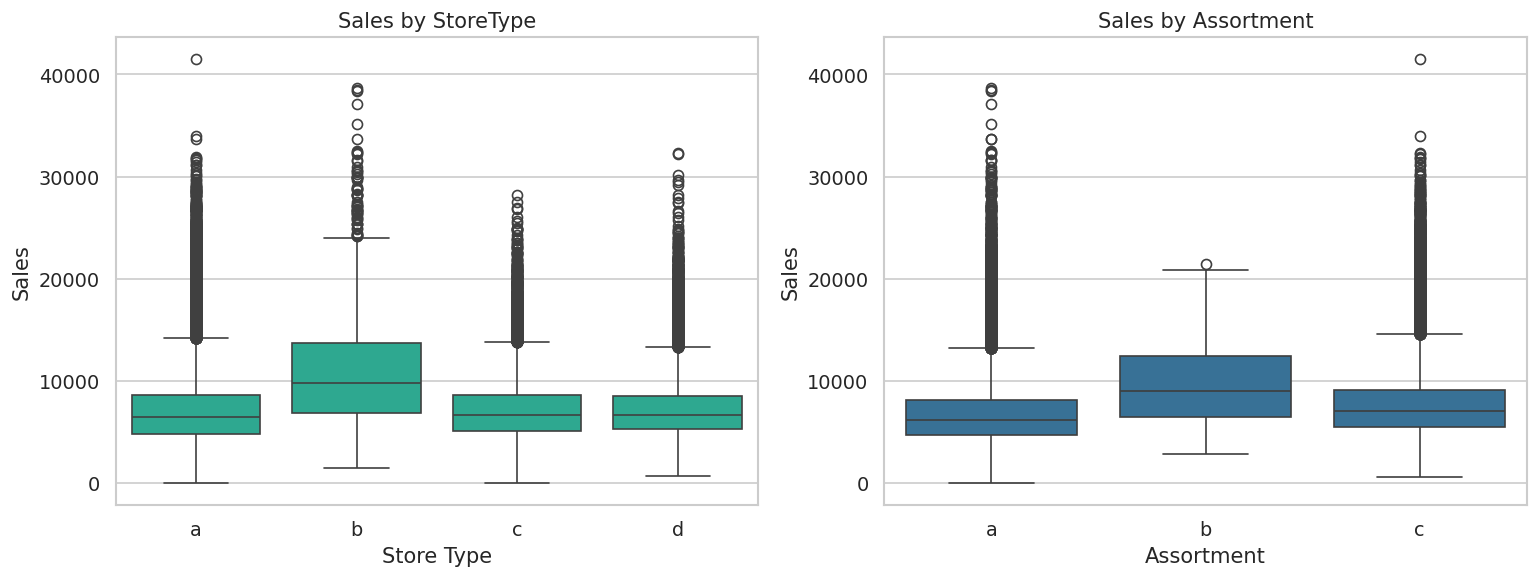

In [ ]:
# Sales vs StoreType / Assortment
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(
    data=open_train,
    x="StoreType",
    y="Sales",
    order=["a", "b", "c", "d"],
    ax=axes[0],
    color="#1ABC9C"
)

axes[0].set_title("Sales by StoreType")
axes[0].set_xlabel("Store Type")
axes[0].set_ylabel("Sales")


sns.boxplot(
    data=open_train,
    x="Assortment",
    y="Sales",
    order=["a", "b", "c"],
    ax=axes[1],
    color="#2874A6"
)

axes[1].set_title("Sales by Assortment")
axes[1].set_xlabel("Assortment")
axes[1].set_ylabel("Sales")

plt.tight_layout()
plt.show()



* Store Type b has the highest median sales and the widest sales distribution.
* Store Types a, c, and d have relatively similar median sales, lower than Type b.
* For assortment, Assortment b shows the highest median sales compared with a and c.
* Assortment a and c have similar sales distributions, with a slightly lower median for a.
* Both plots contain several high-sales outliers, indicating exceptional store performance.
* Overall, Store Type b and Assortment b appear to be associated with higher sales.

Text(0.5, 1.0, 'Mean Sales by Month')

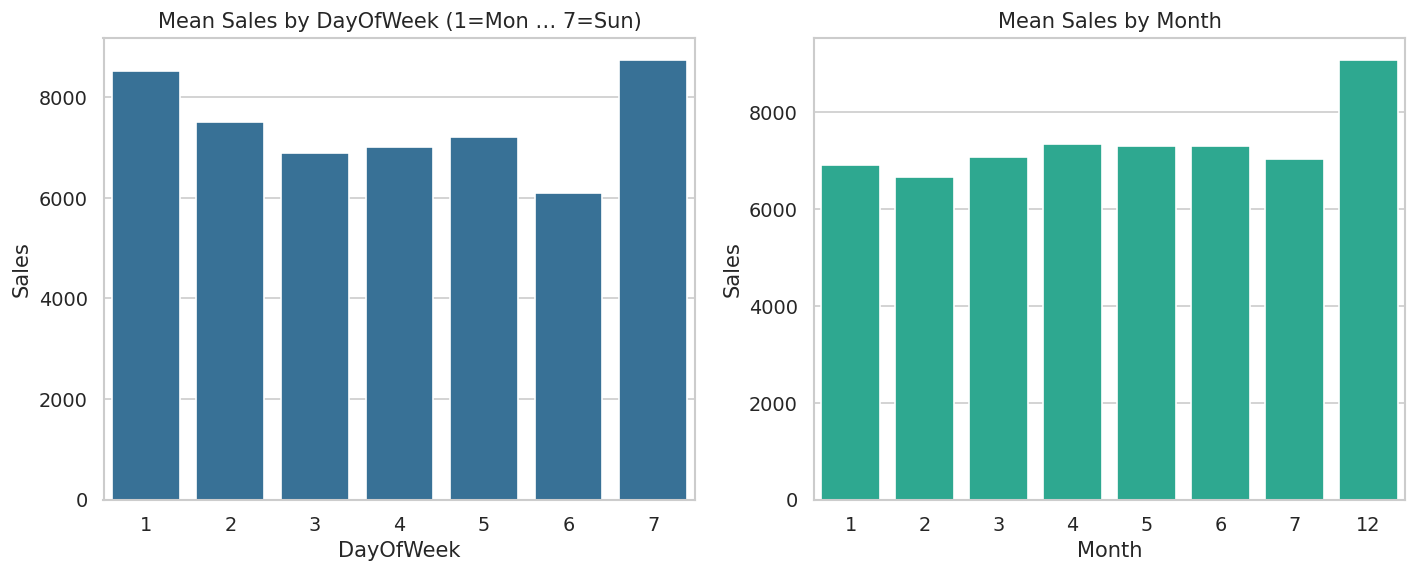

In [ ]:
# Sales vs DayOfWeek / Month
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=open_train, x="DayOfWeek", y="Sales", ax=axes[0], errorbar=None, color="#2874A6")
axes[0].set_title("Mean Sales by DayOfWeek (1=Mon … 7=Sun)")
sns.barplot(data=open_train, x="Month", y="Sales", ax=axes[1], errorbar=None, color="#1ABC9C")
axes[1].set_title("Mean Sales by Month")


* Monday (Day 1) and Sunday (Day 7) have the highest average sales.
* Saturday (Day 6) records the lowest average sales during the week.
* Sales generally remain between 6,000 and 8,500 across the days.
* Monthly sales are relatively stable from January to July.
* December (Month 12) has a significant increase and the highest average sales.
* Overall, day-of-week and seasonal/monthly patterns have a noticeable impact on Rossmann sales.

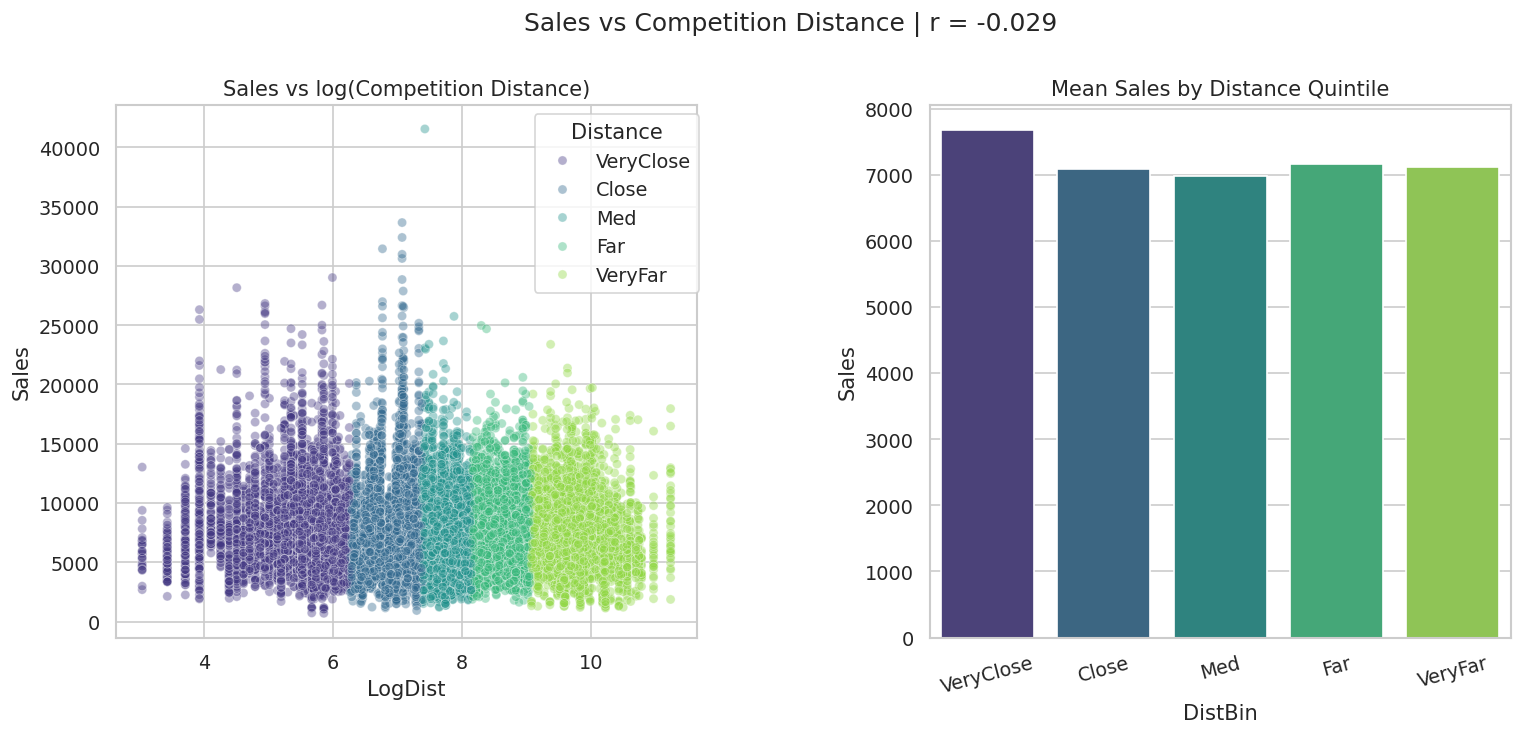

In [ ]:
# Sales vs CompetitionDistance
comp_df = open_train[open_train["CompetitionDistance"].notna() & (open_train["CompetitionDistance"] > 0)].copy()
comp_df["LogDist"] = np.log1p(comp_df["CompetitionDistance"])
corr_dist = comp_df[["Sales", "CompetitionDistance"]].corr().iloc[0, 1]
comp_df["DistBin"] = pd.qcut(comp_df["CompetitionDistance"], 5,
                             labels=["VeryClose", "Close", "Med", "Far", "VeryFar"])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sample = comp_df.sample(min(25000, len(comp_df)), random_state=42)

sns.scatterplot(data=sample, x="LogDist", y="Sales", hue="DistBin",
                palette="viridis", alpha=0.4, s=30, ax=axes[0])
axes[0].set_title("Sales vs log(Competition Distance)")
axes[0].legend(title="Distance", bbox_to_anchor=(1.02, 1))

sns.barplot(data=comp_df, x="DistBin", y="Sales", hue="DistBin",
            palette="viridis", errorbar=None, legend=False, ax=axes[1])
axes[1].set_title("Mean Sales by Distance Quintile")
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle(f"Sales vs Competition Distance | r = {corr_dist:.3f}", fontsize=15)
plt.subplots_adjust(wspace=0.4, top=0.85)
plt.show()


* The EDA examines the relationship between sales and competition distance in Rossmann stores.
* The correlation is -0.029, indicating almost no linear relationship between the two variables.
* Sales vary considerably across stores, regardless of their distance from competitors.
* Stores in the VeryClose category have the highest average sales.
* The Med category has the lowest average sales, but the difference is relatively small.
* Competition distance is not a strong predictor of sales, so other factors likely have greater influence.

In [ ]:
open_train = open_train.rename(columns={
    "Promo2_x": "Promo2"
})


2026-09-08 14:15:47,395 - eda_task1 - INFO - Bivariate analysis completed.


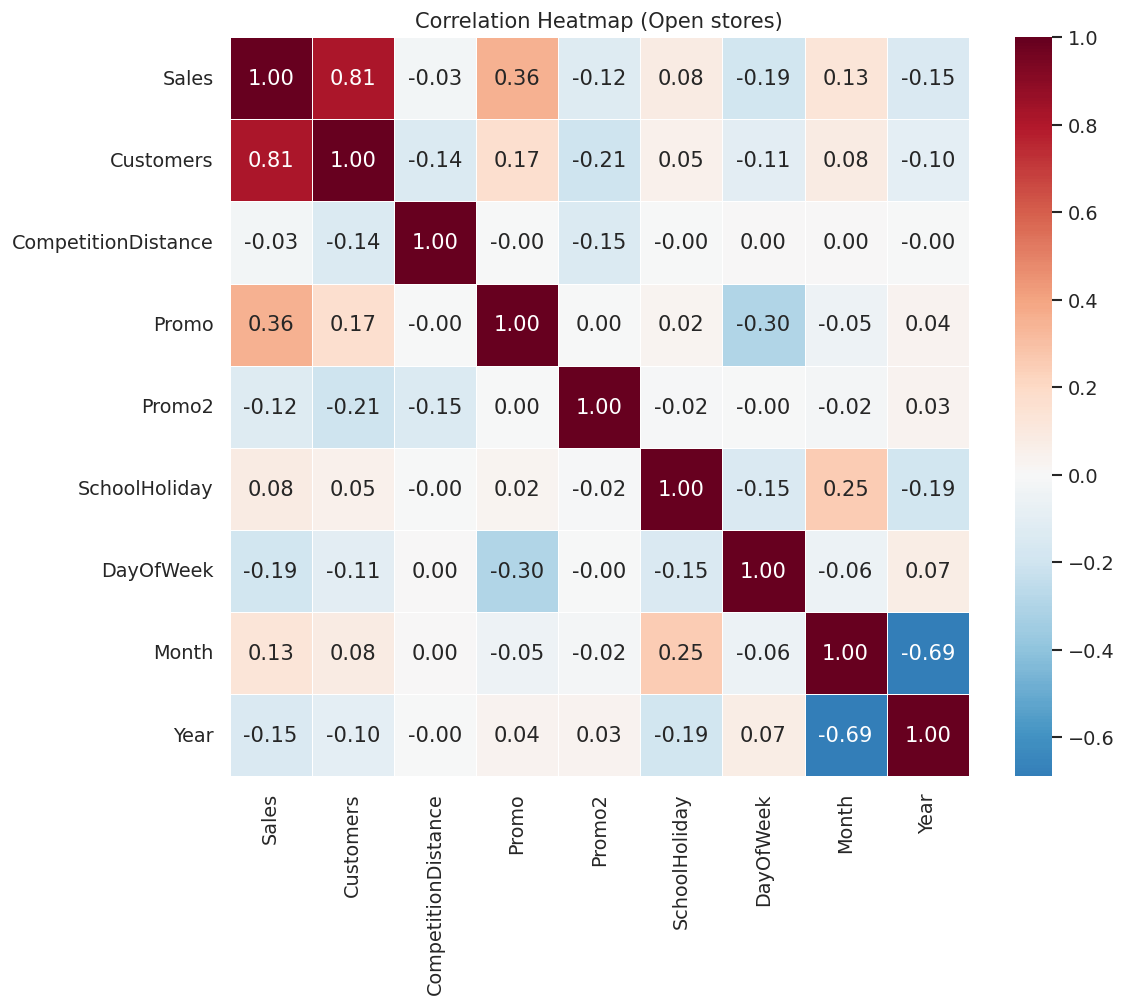

In [ ]:
#Correlation heatmap (numeric)
num_cols = ["Sales", "Customers", "CompetitionDistance", "Promo", "Promo2",
            "SchoolHoliday", "DayOfWeek", "Month", "Year"]
corr_mat = open_train[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, ax=ax, linewidths=0.5)
ax.set_title("Correlation Heatmap (Open stores)")
logger.info("Bivariate analysis completed.")

* Customers and Sales have a strong positive correlation (0.81), making customers the strongest sales-related factor.
* Promo and Sales show a moderate positive correlation (0.36), suggesting promotions can increase sales.
* DayOfWeek and Sales have a weak negative correlation (-0.19).
* CompetitionDistance and Sales show almost no relationship (-0.03).
* Month and Sales have a weak positive correlation (0.13), while Year and Sales show a weak negative correlation (-0.15).
* Customers and promotions are more influential on sales than competition distance or calendar variables.

MULTIVARIATE ANALYSIS

2026-09-08 14:18:22,971 - eda_task1 - INFO - 
Promo × StoreType mean Sales:
Promo            0        1
StoreType                  
a           5965.0   8410.0
b          10094.0  11876.0
c           6243.0   8260.0
d           6191.0   8353.0


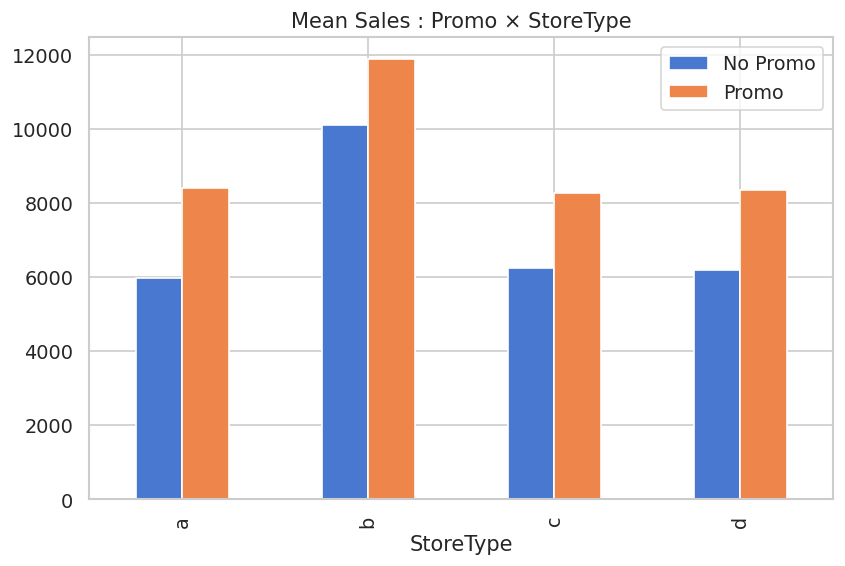

In [ ]:
# Promo × StoreType
pivot_st = open_train.pivot_table(values="Sales", index="StoreType", columns="Promo", aggfunc="mean")
logger.info(f"\nPromo × StoreType mean Sales:\n{pivot_st.round(0)}")

fig, ax = plt.subplots(figsize=(8, 5))
pivot_st.plot(kind="bar", ax=ax)
ax.set_title("Mean Sales : Promo × StoreType")
ax.legend(["No Promo", "Promo"])

* The EDA of the Rossmann dataset helps understand how sales vary across store types and promotions.
* From the graph, Store Type B has the highest average sales, both with and without promotion.
* Promotions generally increase average sales across all store types, showing a positive promotional impact.
* Store Types A, C, and D also show a clear sales uplift when promotions are active.
* Other important factors explored in Rossmann EDA include customers, seasonality, holidays, competition, and store characteristics.
* The analysis suggests that store type and promotional campaigns are important drivers of sales and can support better sales forecasting and business decisions.

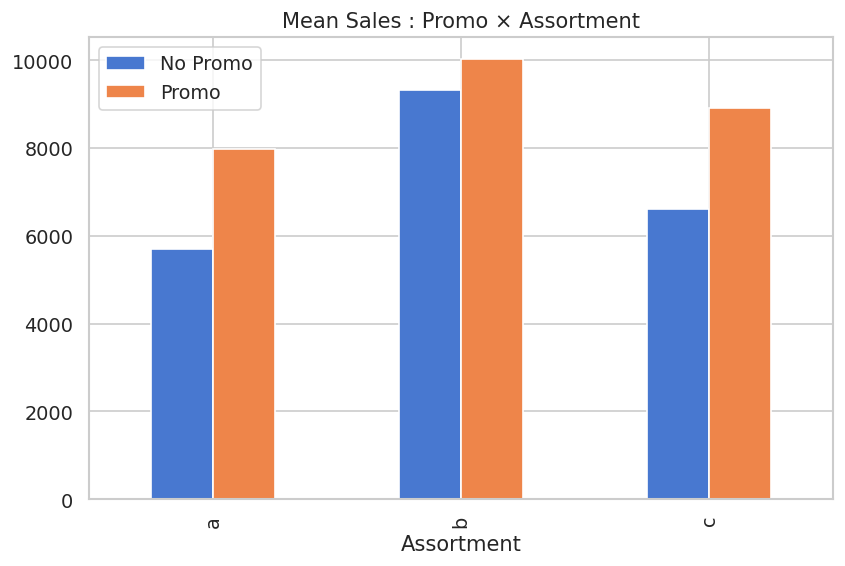

In [ ]:
# Promo × Assortment
pivot_as = open_train.pivot_table(values="Sales", index="Assortment", columns="Promo", aggfunc="mean")
fig, ax = plt.subplots(figsize=(8, 5))
pivot_as.plot(kind="bar", ax=ax)
ax.set_title("Mean Sales : Promo × Assortment")
ax.legend(["No Promo", "Promo"])

* EDA on the Rossmann Pharmaceuticals sales dataset helps identify the key factors influencing daily store sales.
* The analysis shows that promotions have a strong positive impact on sales, as promo days generally generate higher revenue.
* From the given chart, Assortment B has the highest average sales, both with and without promotions.
* Assortment C also performs well, while Assortment A records the lowest average sales.
Other important factors explored in EDA include customers, store type, holidays, competition distance, and seasonal/weekly trends.
* EDA helps identify sales patterns and important features that can be used for sales forecasting and business decision-making

Text(0.5, 1.0, 'Sales : StoreType × Assortment')

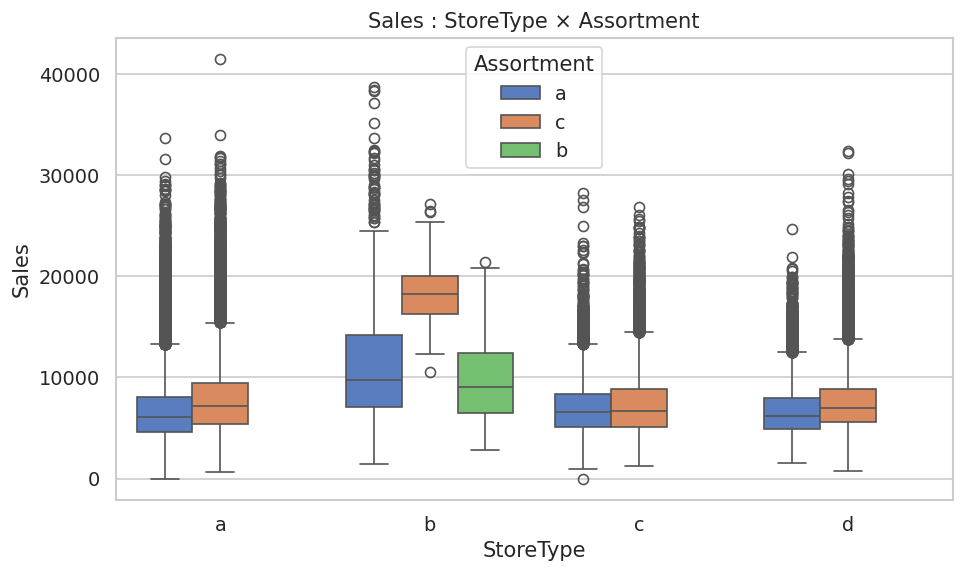

In [ ]:
# StoreType × Assortment
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=open_train, x="StoreType", y="Sales", hue="Assortment",
            order=["a","b","c","d"], ax=ax)
ax.set_title("Sales : StoreType × Assortment")

* The boxplot shows that Store Type b generally has the highest sales, especially for Assortment c.
* Store Types a, c, and d show relatively lower median sales compared with Type b.
* Across most store types, Assortment c tends to have higher sales than Assortment a.
* There are many outliers, indicating some stores achieve exceptionally high sales.
* Store Type b has a wider sales distribution, suggesting greater variation in its performance.
* Store Type and Assortment are important factors influencing Rossmann store sales.

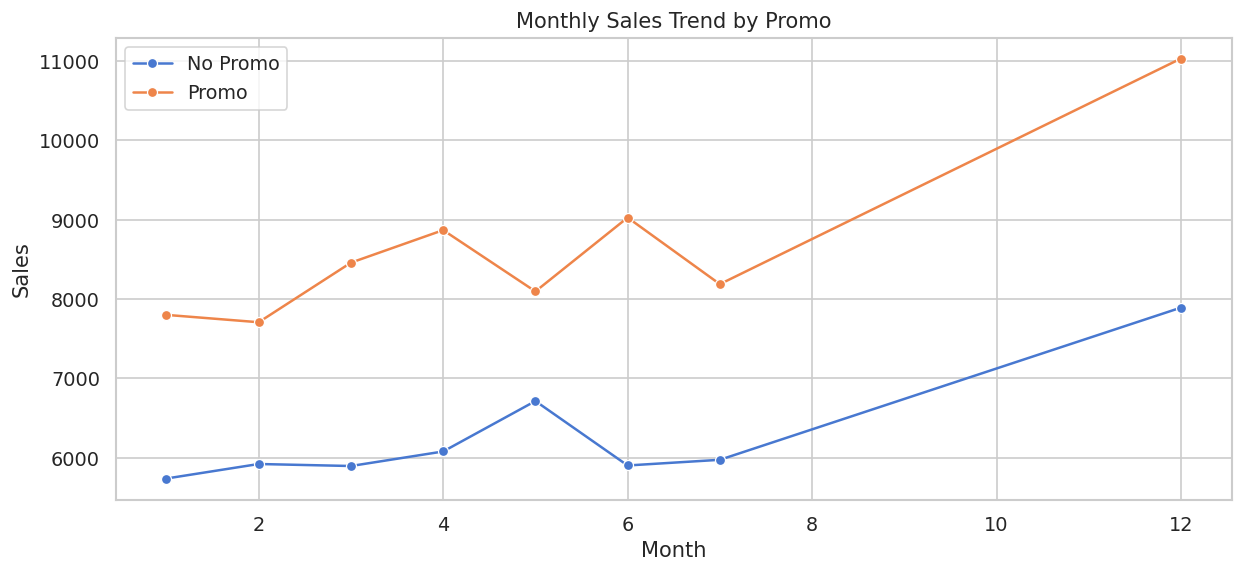

In [ ]:
# Month × Promo
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=open_train, x="Month", y="Sales", hue="Promo",
             marker="o", errorbar=None, ax=ax)
ax.set_title("Monthly Sales Trend by Promo")
ax.legend(["No Promo", "Promo"])

Text(0.5, 1.0, 'Sales by DayOfWeek × StoreType')

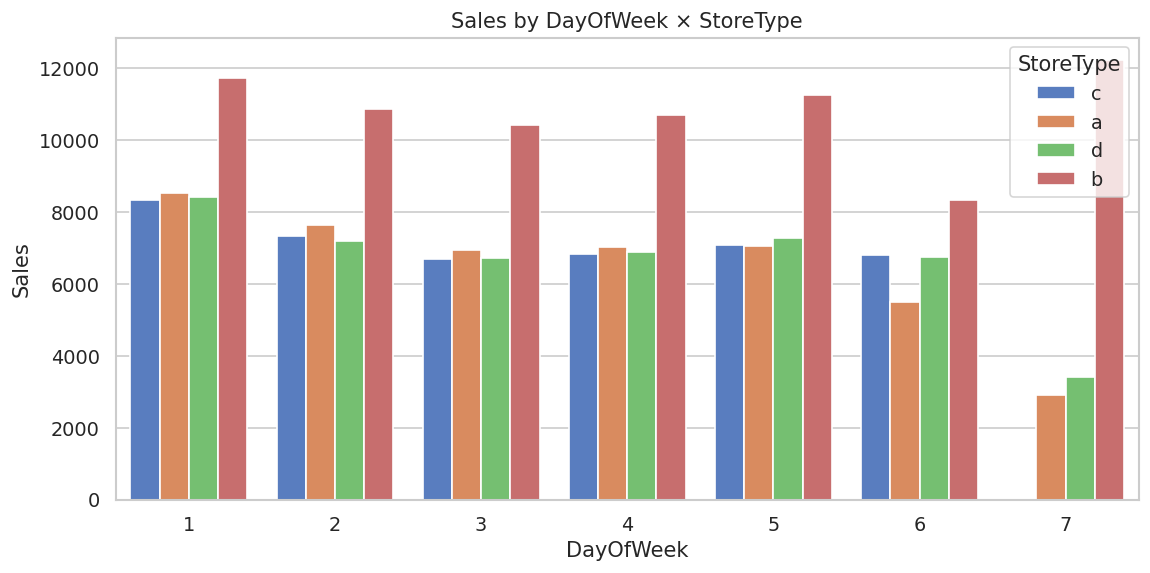

In [ ]:
# DayOfWeek × StoreType
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=open_train, x="DayOfWeek", y="Sales", hue="StoreType",
            errorbar=None, ax=ax)
ax.set_title("Sales by DayOfWeek × StoreType")

2026-09-08 14:19:04,324 - eda_task1 - INFO - Multivariate analysis completed.


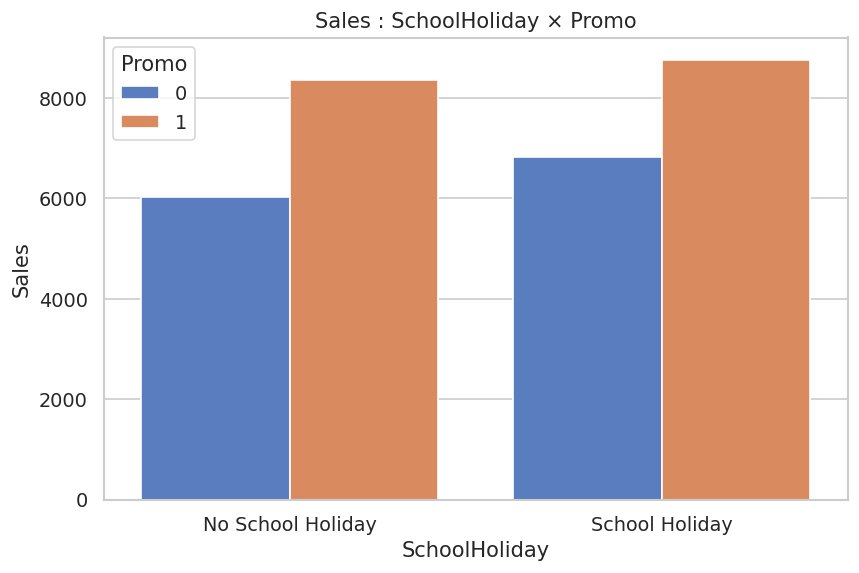

In [ ]:
# SchoolHoliday × Promo
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=open_train, x="SchoolHoliday", y="Sales", hue="Promo",
            errorbar=None, ax=ax)
ax.set_title("Sales : SchoolHoliday × Promo")
ax.set_xticklabels(["No School Holiday", "School Holiday"])
logger.info("Multivariate analysis completed.")

TRAIN vs TEST FEATURE COMPARISON

In [ ]:
train = train.rename(columns={"Promo2_x": "Promo2"})
train = train.drop(columns=["Promo2_y"], errors="ignore")

open_train = open_train.drop(columns=["Promo2_y"], errors="ignore")


In [ ]:
print("Train Promo columns:",
      [c for c in train.columns if "Promo" in c])

print("Test Promo columns:",
      [c for c in test.columns if "Promo" in c])

print("Open_train Promo columns:",
      [c for c in open_train.columns if "Promo" in c])


Train Promo columns: ['Promo', 'Promo2', 'PromoInterval']
Test Promo columns: ['Promo', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']
Open_train Promo columns: ['Promo', 'Promo2', 'PromoInterval']


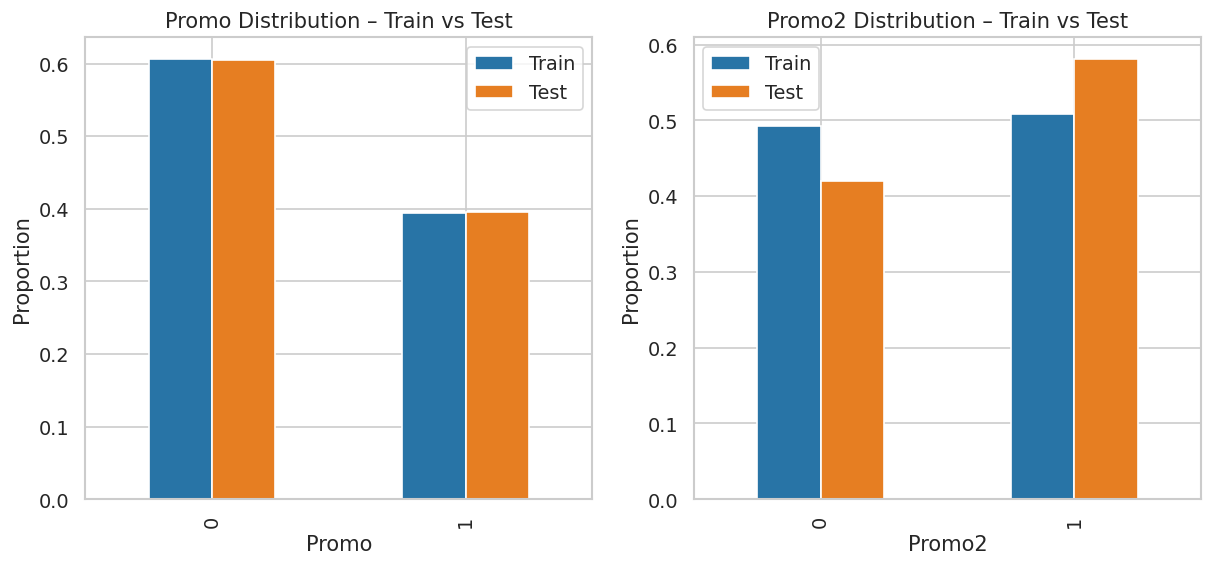

In [ ]:
# Promo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, title in zip(axes, ["Promo", "Promo2"], ["Promo", "Promo2"]):
    tr = train[col].value_counts(normalize=True).sort_index()
    te = test[col].value_counts(normalize=True).sort_index()
    pd.DataFrame({"Train": tr, "Test": te}).plot(kind="bar", ax=ax, color=["#2874A6", "#E67E22"])
    ax.set_title(f"{title} Distribution – Train vs Test")
    ax.set_ylabel("Proportion")

In [ ]:
print("Train:")
print([c for c in train.columns if "StoreType" in c or "Assortment" in c])

print("\nTest:")
print([c for c in test.columns if "StoreType" in c or "Assortment" in c])



Train:
['StoreType_x', 'Assortment_x', 'StoreType_y', 'Assortment_y']

Test:
['StoreType', 'Assortment']


In [ ]:
if "StoreType_x" in train.columns:
    train = train.rename(columns={"StoreType_x": "StoreType"})

if "Assortment_x" in train.columns:
    train = train.rename(columns={"Assortment_x": "Assortment"})

train = train.drop(
    columns=["StoreType_y", "Assortment_y"],
    errors="ignore"
)


In [ ]:
print([c for c in train.columns if "StoreType" in c or "Assortment" in c])


['StoreType', 'Assortment']


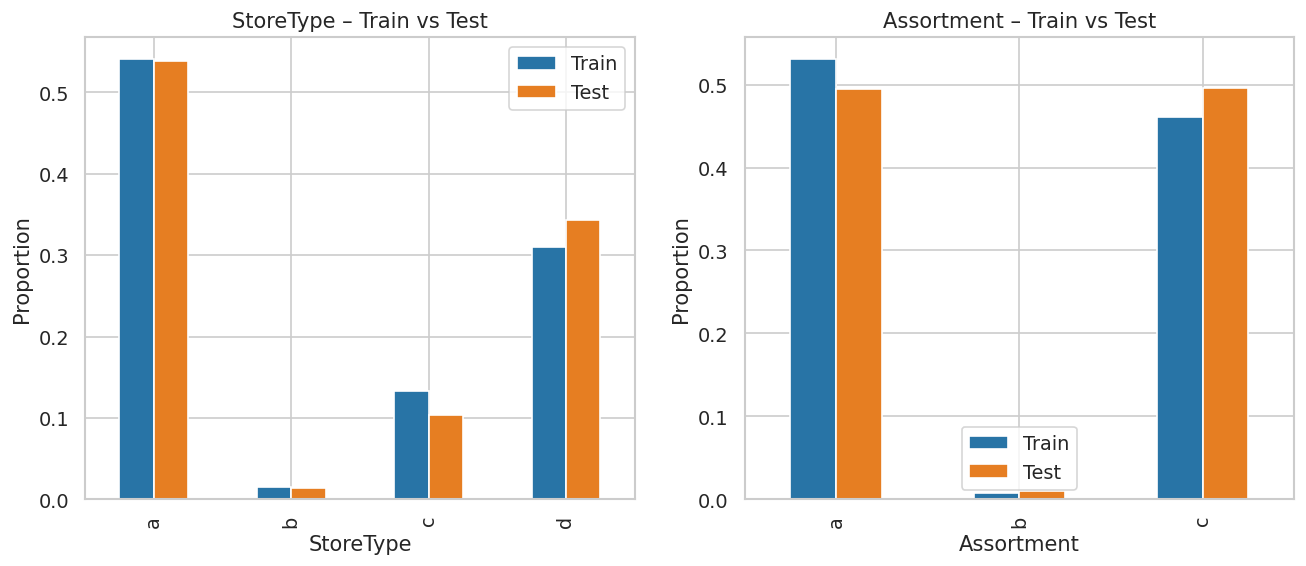

In [ ]:
# StoreType & Assortment
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col in zip(axes, ["StoreType", "Assortment"]):
    tr = train[col].value_counts(normalize=True).sort_index()
    te = test[col].value_counts(normalize=True).sort_index()
    pd.DataFrame({"Train": tr, "Test": te}).plot(kind="bar", ax=ax, color=["#2874A6", "#E67E22"])
    ax.set_title(f"{col} – Train vs Test")
    ax.set_ylabel("Proportion")

(0.0, 50000.0)

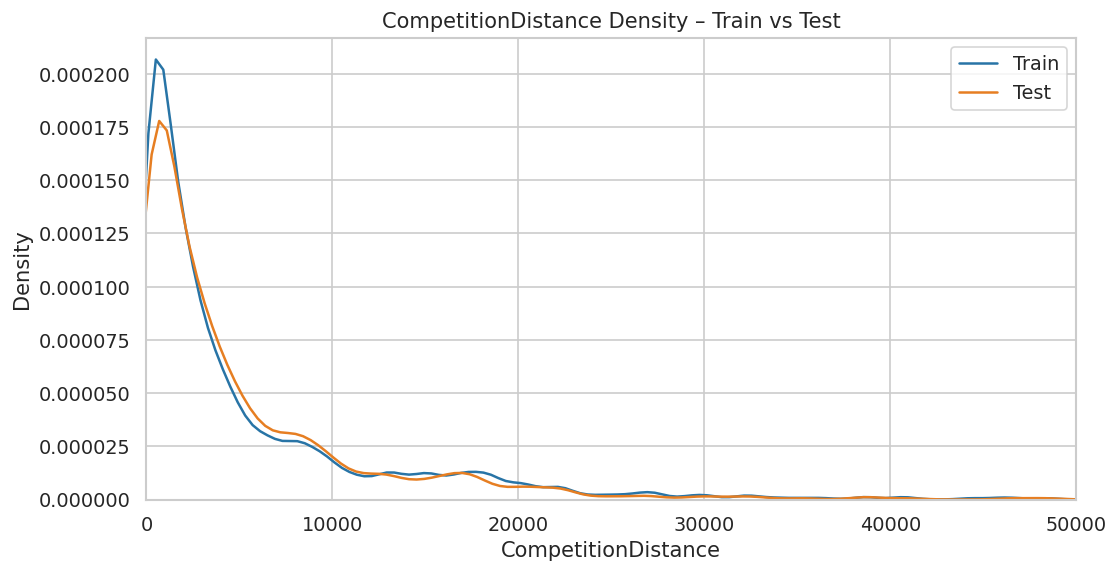

In [ ]:
# CompetitionDistance
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(train["CompetitionDistance"].dropna(), label="Train", ax=ax, color="#2874A6")
sns.kdeplot(test["CompetitionDistance"].dropna(),  label="Test",  ax=ax, color="#E67E22")
ax.set_title("CompetitionDistance Density – Train vs Test")
ax.legend()
ax.set_xlim(0, 50000)

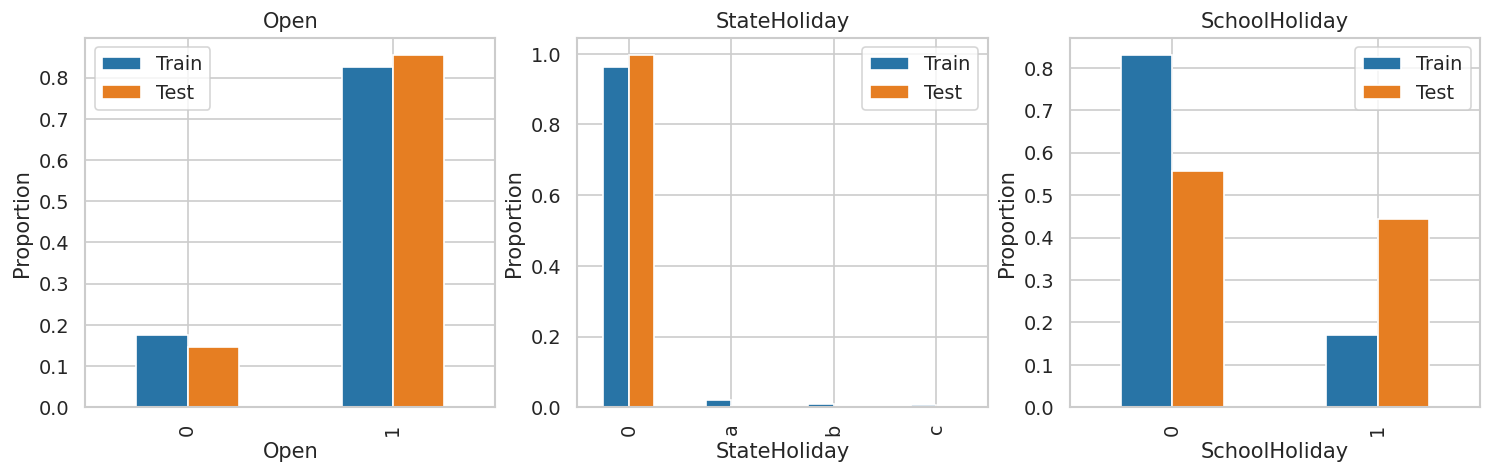

In [ ]:
# Open / StateHoliday / SchoolHoliday
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Open", "StateHoliday", "SchoolHoliday"]):
    tr = train[col].value_counts(normalize=True).sort_index()
    te = test[col].value_counts(normalize=True).sort_index()
    pd.DataFrame({"Train": tr, "Test": te}).plot(kind="bar", ax=ax, color=["#2874A6", "#E67E22"])
    ax.set_title(col)
    ax.set_ylabel("Proportion")

In [ ]:
logger.info("Train vs Test comparison completed.")
logger.info("Observation: Promo, StoreType, Assortment distributions are very similar → low covariate shift risk.")

2026-09-08 14:39:02,575 - eda_task1 - INFO - Train vs Test comparison completed.
2026-09-08 14:39:02,585 - eda_task1 - INFO - Observation: Promo, StoreType, Assortment distributions are very similar → low covariate shift risk.


QUESTIONS

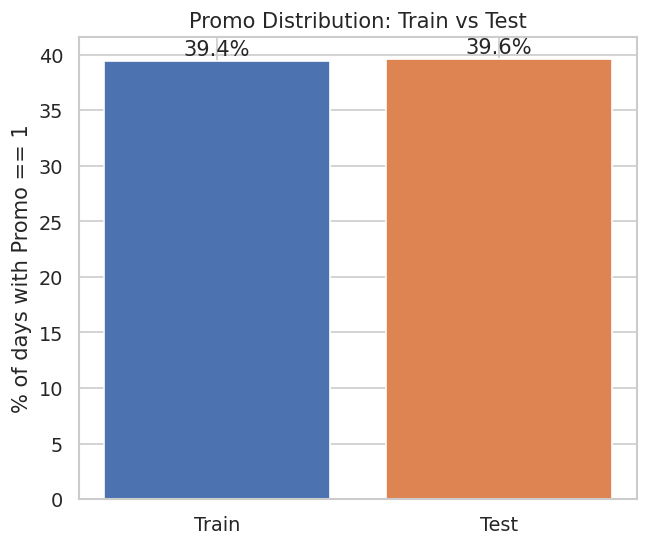

2026-09-08 14:39:05,367 - eda_task1 - INFO - Promo % in train: 39.41%  |  Promo % in test: 39.58%


In [ ]:
 #1. Are promotions distributed similarly between train and test sets?

promo_train_pct = train['Promo'].mean() * 100
promo_test_pct = test['Promo'].mean() * 100

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['Train', 'Test'], [promo_train_pct, promo_test_pct], color=['#4C72B0', '#DD8452'])
ax.set_ylabel('% of days with Promo == 1')
ax.set_title('Promo Distribution: Train vs Test')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.1f}%', ha='center')
plt.show()

logger.info(f"Promo % in train: {promo_train_pct:.2f}%  |  Promo % in test: {promo_test_pct:.2f}%")

Insight:** Compare the two bars above. If the percentages are close (they typically land within a few points of each other for this dataset), promotions are distributed **similarly** across train and test — which is good news: it means the model won't need to extrapolate to a promo regime it never saw during training. If there's a large gap, note it as a distribution-shift risk worth flagging before modeling.

In [ ]:
# Q1,b- Full Train vs Test Distribution Check (all shared features)
# Q1 only checked `Promo`. But **every** feature that exists in both `store_train`
# and `store_test` is worth checking — if test skews toward store types, holiday
# patterns, or competition profiles the model barely saw in training, the 6-week
# forecast will be weaker exactly for those cases. This section checks all of them
# systematically: which `Store` IDs appear in each set, then every shared categorical
#  and numeric column.

#Which stores appear in train vs test?
train_stores = set(train['Store'].unique())
test_stores = set(test['Store'].unique())

only_in_train = train_stores - test_stores
only_in_test = test_stores - train_stores
in_both = train_stores & test_stores

logger.info(f"Stores in train: {len(train_stores)}")
logger.info(f"Stores in test:  {len(test_stores)}")
logger.info(f"Stores in BOTH:  {len(in_both)}")
logger.info(f"Stores ONLY in train (never appear in test): {len(only_in_train)}")
logger.info(f"Stores ONLY in test (never appear in train): {len(only_in_test)}")

2026-09-08 14:39:09,898 - eda_task1 - INFO - Stores in train: 1115
2026-09-08 14:39:09,899 - eda_task1 - INFO - Stores in test:  856
2026-09-08 14:39:09,901 - eda_task1 - INFO - Stores in BOTH:  856
2026-09-08 14:39:09,902 - eda_task1 - INFO - Stores ONLY in train (never appear in test): 259
2026-09-08 14:39:09,903 - eda_task1 - INFO - Stores ONLY in test (never appear in train): 0


Every store in `test` should also appear in `train` (test is a future time-slice of the same store network, not new stores) — `only_in_test` should be empty; if it isn't, that's a serious problem since the model would have zero history for those stores. `only_in_train` being non-empty is normal — it just means the finance team isn't forecasting **every** store this round, only the ones present in `store_test`. Note this doesn't affect training itself (the model still learns from all `train` stores), only which stores get predictions this cycle.

read the `Difference (pts)` column in each table above:**
- **`DayOfWeek`** and **`SchoolHoliday`** should be fairly close between train/test since both span full weeks — big gaps here would be unusual and worth double-checking your date parsing.
- **`StateHoliday`**: test only covers Aug 1 – Sep 17, 2015 (~7 weeks), so it simply won't contain Christmas/Easter-type holidays that are common in the full 2.5-year train set. A large difference here is **expected and not a bug** — it's a direct consequence of the test window's short, holiday-sparse calendar range. Worth remembering when trusting the model's later-year holiday predictions.
- **`StoreType`, `Assortment`, `Promo2`, `PromoInterval`**: these are static, store-level attributes. Any gap here reflects the *specific subset of stores* chosen for the test set (see the store-overlap check above), not a data-quality issue — but a large gap does mean the model will be validated on a somewhat different store mix than it trained on.

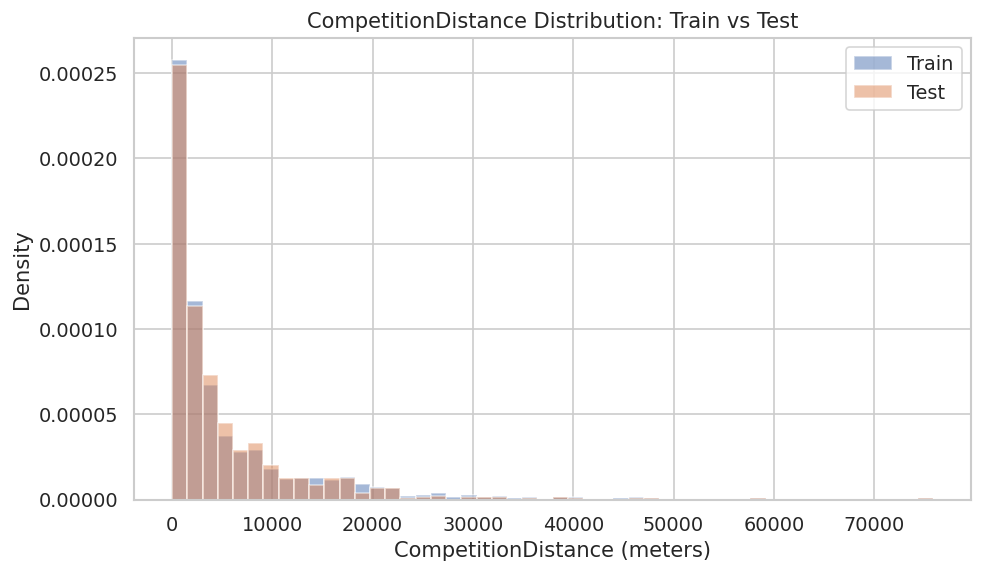

               Train          Test
count  252322.000000  41088.000000
mean     5406.019095   5082.126168
std      7671.881578   7218.274638
min        20.000000     20.000000
25%       720.000000    720.000000
50%      2325.000000   2410.000000
75%      6880.000000   6435.000000
max     75860.000000  75860.000000


In [ ]:
#  Numeric feature: `CompetitionDistance

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(train['CompetitionDistance'], bins=50, alpha=0.5, label='Train', density=True, color='#4C72B0')
ax.hist(test['CompetitionDistance'], bins=50, alpha=0.5, label='Test', density=True, color='#DD8452')
ax.set_xlabel('CompetitionDistance (meters)')
ax.set_ylabel('Density')
ax.set_title('CompetitionDistance Distribution: Train vs Test')
ax.legend()
plt.show()

print(pd.DataFrame({
    'Train': train['CompetitionDistance'].describe(),
    'Test': test['CompetitionDistance'].describe()
}))

Compare the two describe() columns and the overlap of the histograms. Since `CompetitionDistance` is a static per-store value, any difference here is again about *which stores* landed in the test set, not about time-based drift. If test stores skew toward much closer/farther competitors than the training population, the model will have less relevant training signal for that segment.

In [ ]:
#2. Sales behaviour before, during, and after holidays #CHECK

sdf = train.sort_values(['Store', 'Date']).copy()
sdf['NextDayIsHoliday'] = sdf.groupby('Store')['IsStateHoliday'].shift(-1)
sdf['PrevDayIsHoliday'] = sdf.groupby('Store')['IsStateHoliday'].shift(1)

               Period    Avg Sales  N rows
0          Normal day  7128.760301  191010
1  Day before holiday  7884.780117    6317
2      Holiday itself  9492.054152     277
3   Day after holiday  7502.385042    8664


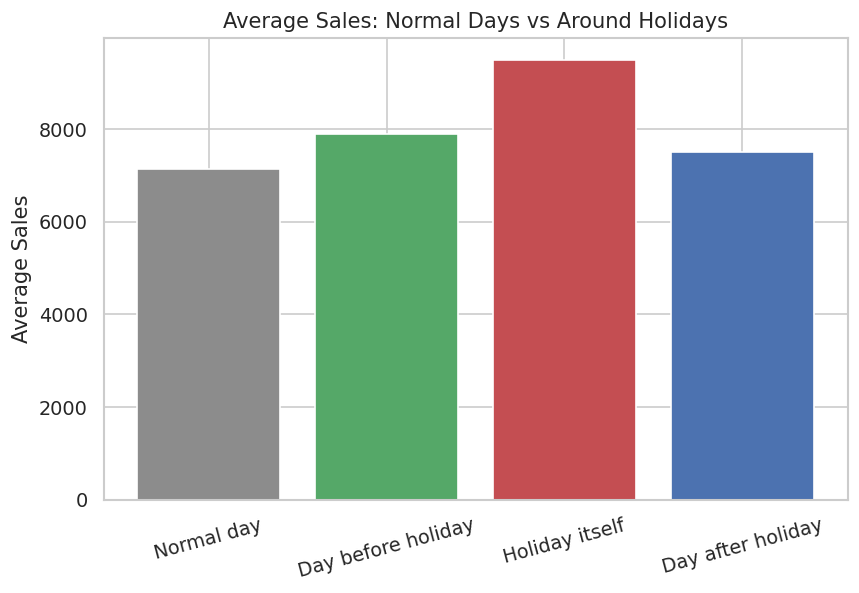

In [ ]:
# Only compare rows where the store was actually open and selling (Sales > 0) for a fair comparison
sdf_open = sdf[(sdf['Open'] == 1) & (sdf['Sales'] > 0)]

before_holiday = sdf_open[(sdf_open['NextDayIsHoliday'] == 1) & (sdf_open['IsStateHoliday'] == 0)]['Sales']
during_holiday = sdf_open[sdf_open['IsStateHoliday'] == 1]['Sales']
after_holiday = sdf_open[(sdf_open['PrevDayIsHoliday'] == 1) & (sdf_open['IsStateHoliday'] == 0)]['Sales']
normal_day = sdf_open[(sdf_open['IsStateHoliday'] == 0) & (sdf_open['NextDayIsHoliday'] == 0) & (sdf_open['PrevDayIsHoliday'] == 0)]['Sales']

summary = pd.DataFrame({
    'Period': ['Normal day', 'Day before holiday', 'Holiday itself', 'Day after holiday'],
    'Avg Sales': [normal_day.mean(), before_holiday.mean(), during_holiday.mean(), after_holiday.mean()],
    'N rows': [len(normal_day), len(before_holiday), len(during_holiday), len(after_holiday)]
})
print(summary)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(summary['Period'], summary['Avg Sales'], color=['#8C8C8C', '#55A868', '#C44E52', '#4C72B0'])
ax.set_ylabel('Average Sales')
ax.set_title('Average Sales: Normal Days vs Around Holidays')
plt.xticks(rotation=15)
plt.show()

The day **before** a holiday typically shows a sales spike (last-minute stocking-up behaviour). Sales **on** the holiday itself are usually much lower on average — remember most stores are closed on state holidays, so this average is driven by the few exceptions still trading. The day **after** often dips slightly below normal before returning to baseline (customers already bought what they needed). This "pre-holiday spike" is a strong candidate feature for modeling — a simple `IsHoliday` flag alone would miss it.

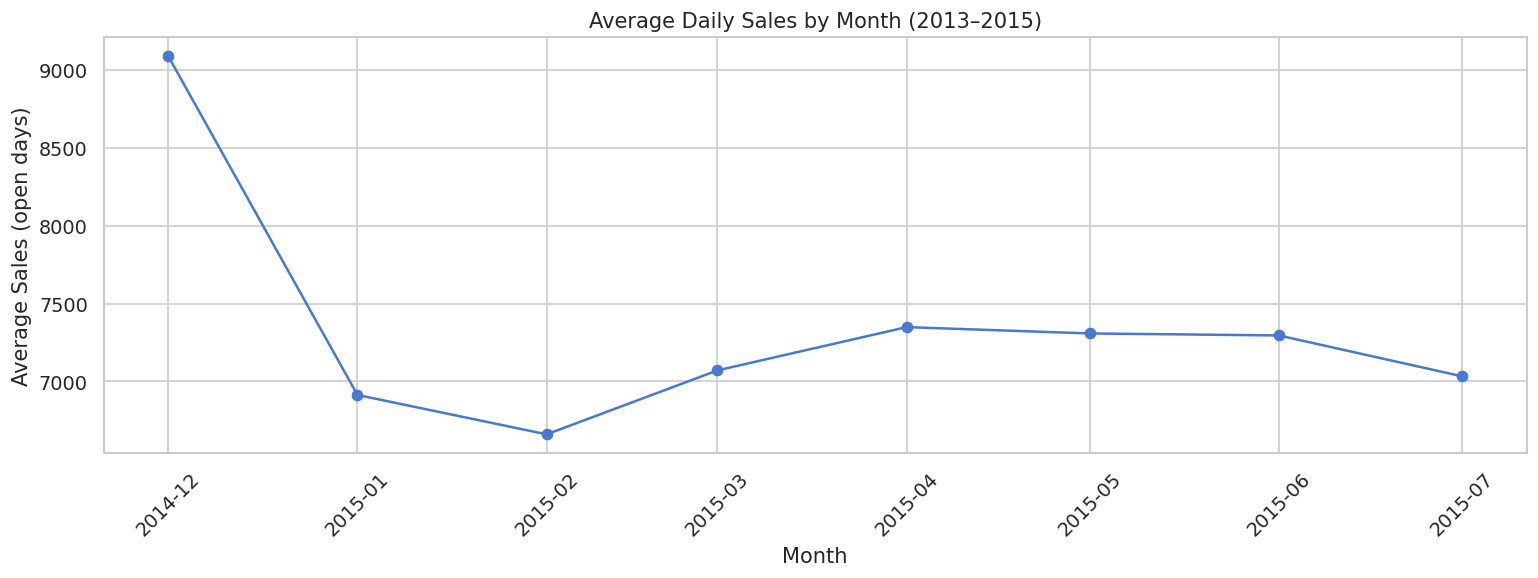

          Holiday  Avg Sales (open days trading on it)  N days
0  Public Holiday                          9084.357513     193
1          Easter                         10518.244898      49
2       Christmas                         10303.542857      35
                     mean  median   count
Rest of year  7088.126648  6530.0  196032
December      9089.412990  8500.0   12240


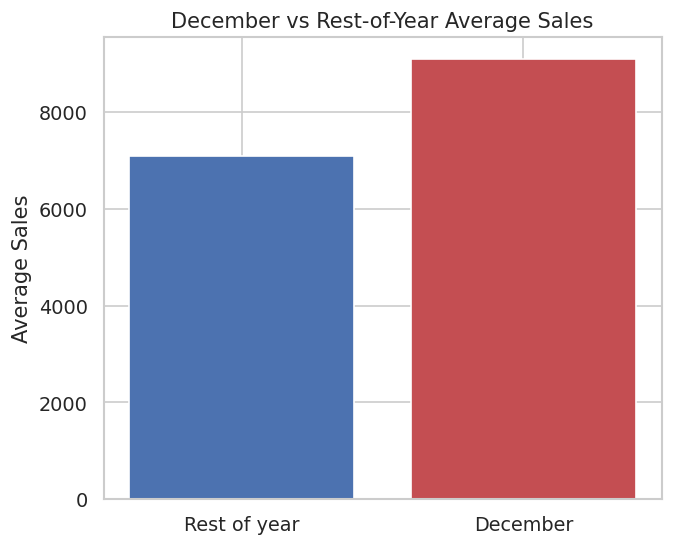

In [ ]:
#3. Seasonal purchase behaviour (Christmas, Easter, etc.

# Keep only days when stores were open
open_df = train[train['Open'] == 1]

# Sorted version for holiday-related analysis
sdf_open = open_df.sort_values(['Store', 'Date'])


monthly_avg = open_df.groupby(['Year', 'Month'])['Sales'].mean().reset_index()
monthly_avg['YearMonth'] = pd.to_datetime(monthly_avg[['Year', 'Month']].assign(DAY=1))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly_avg['YearMonth'], monthly_avg['Sales'], marker='o')
ax.set_title('Average Daily Sales by Month (2013–2015)')
ax.set_ylabel('Average Sales (open days)')
ax.set_xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Zoom into specific holiday types using StateHoliday codes: a=public, b=Easter, c=Christmas
holiday_labels = {'a': 'Public Holiday', 'b': 'Easter', 'c': 'Christmas'}

results = []
for code_, label in holiday_labels.items():
    mask_during = (sdf_open['StateHoliday'] == code_)
    mask_before = (sdf['StateHoliday'].shift(-1).reindex(sdf_open.index) == code_) if False else None
    results.append({'Holiday': label, 'Avg Sales (open days trading on it)': sdf_open.loc[mask_during, 'Sales'].mean(),
                     'N days': mask_during.sum()})

holiday_type_summary = pd.DataFrame(results)
print(holiday_type_summary)

# December (Christmas run-up) vs rest-of-year average, using the FULL open_df (not just the holiday day itself)
open_df['IsDecember'] = (open_df['Month'] == 12).astype(int)
dec_vs_rest = open_df.groupby('IsDecember')['Sales'].agg(['mean', 'median', 'count'])
dec_vs_rest.index = ['Rest of year', 'December']
print(dec_vs_rest)

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(dec_vs_rest.index, dec_vs_rest['mean'], color=['#4C72B0', '#C44E52'])
ax.set_ylabel('Average Sales')
ax.set_title('December vs Rest-of-Year Average Sales')
plt.show()

The monthly line chart typically shows a clear **December spike** every year (Christmas shopping) and a smaller **March/April bump** some years (Easter, which moves calendar dates year to year — that's why we check the `StateHoliday == 'b'` flag directly rather than a fixed month). December sales average noticeably higher than the rest of the year. This confirms clear **yearly seasonality** — a model that only sees `Promo`/`Open`/day-of-week without any month or "days-to-Christmas" feature will systematically under-predict December sales.

2026-09-08 14:40:14,333 - eda_task1 - INFO - Pearson correlation between Sales and Customers: 0.813


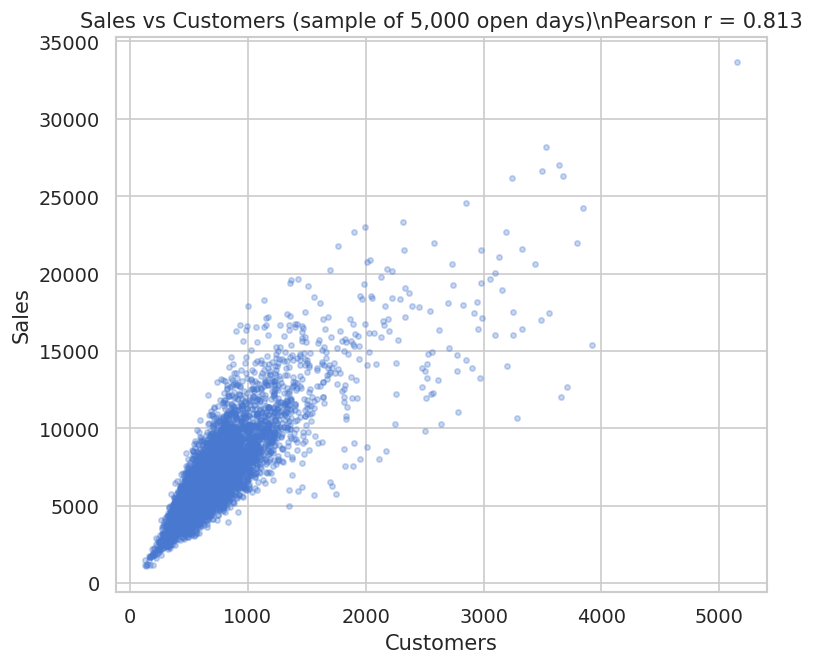

In [ ]:
#4. Correlation between Sales and Customers

correlation = open_df['Sales'].corr(open_df['Customers'])
logger.info(f"Pearson correlation between Sales and Customers: {correlation:.3f}")

# Use a sample for the scatter plot — plotting all ~844K open-day points is slow and unreadable
sample = open_df.sample(n=5000, random_state=42)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(sample['Customers'], sample['Sales'], alpha=0.3, s=10)
ax.set_xlabel('Customers')
ax.set_ylabel('Sales')
ax.set_title(f'Sales vs Customers (sample of 5,000 open days)\\nPearson r = {correlation:.3f}')
plt.show()

Insight:** Sales and Customers are **strongly positively correlated** (Pearson r typically ~0.8+) — unsurprising, since more foot traffic generally means more revenue. But the relationship isn't perfectly linear: the spread widens as Customers increases, meaning **basket size varies** — some days bring fewer customers who spend more each (e.g. during promos, see `SalesPerCustomer` below). This tells us `Customers` alone won't perfectly explain `Sales`; other factors (promo, day type) modulate how much each customer spends.

            Avg_Sales  Avg_Customers  Avg_SalesPerCustomer  N_days
No Promo  6158.105203     699.952077              9.226669  112117
Promo     8427.286953     835.420873             10.535648   96155


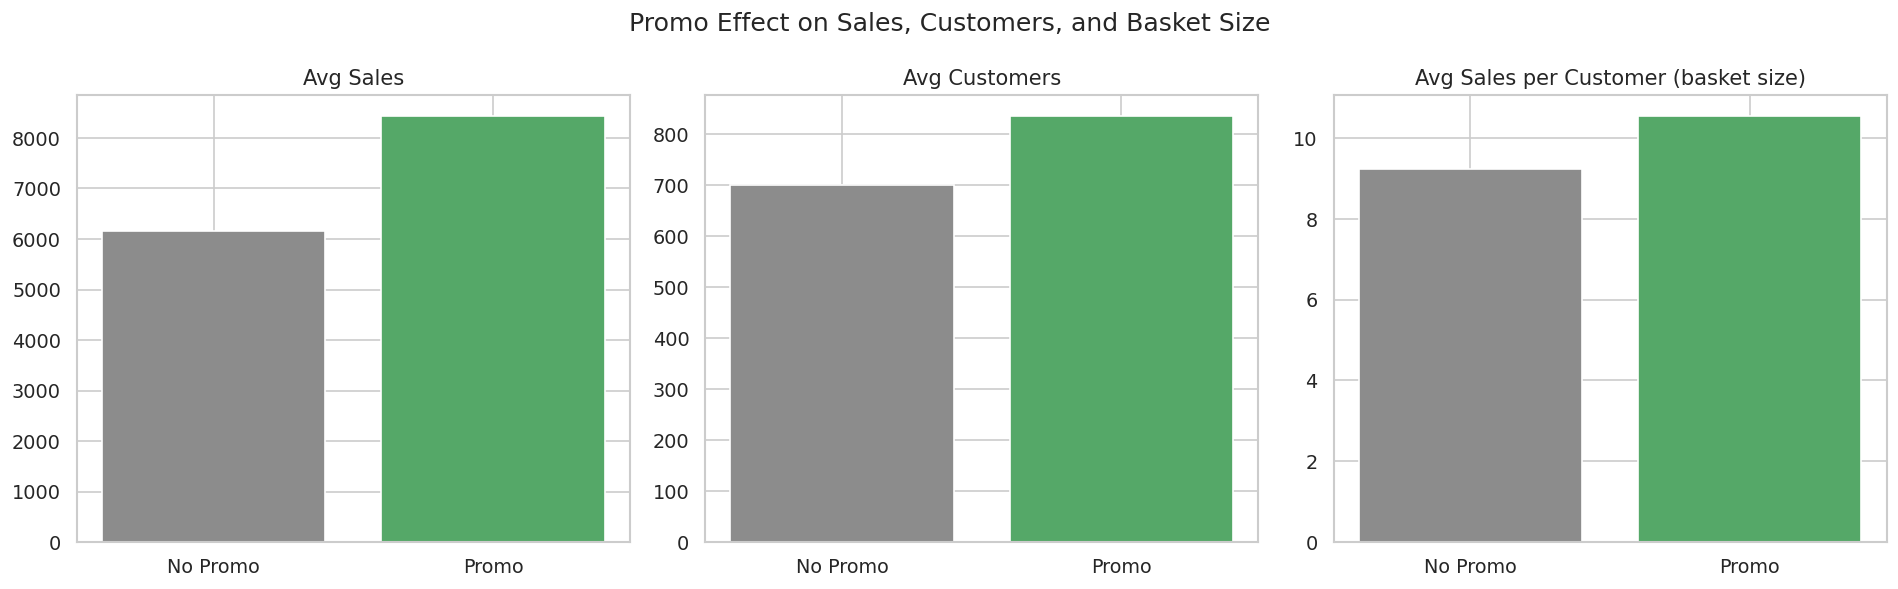

In [ ]:
#5. How does Promo affect Sales and Customers? Does it attract new customers or make existing ones spend more?

open_df['SalesPerCustomer'] = (
    open_df['Sales'] / open_df['Customers']
)

promo_compare = open_df.groupby('Promo').agg(
    Avg_Sales=('Sales', 'mean'),
    Avg_Customers=('Customers', 'mean'),
    Avg_SalesPerCustomer=('SalesPerCustomer', 'mean'),
    N_days=('Sales', 'count')
    )
promo_compare.index = ['No Promo', 'Promo']
print(promo_compare)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(promo_compare.index, promo_compare['Avg_Sales'], color=['#8C8C8C', '#55A868'])
axes[0].set_title('Avg Sales')

axes[1].bar(promo_compare.index, promo_compare['Avg_Customers'], color=['#8C8C8C', '#55A868'])
axes[1].set_title('Avg Customers')

axes[2].bar(promo_compare.index, promo_compare['Avg_SalesPerCustomer'], color=['#8C8C8C', '#55A868'])
axes[2].set_title('Avg Sales per Customer (basket size)')

plt.suptitle('Promo Effect on Sales, Customers, and Basket Size')
plt.tight_layout()
plt.show()

Promo days show higher averages on **all three** metrics — more total sales, more customers walking in, AND a higher spend-per-customer. This means promos aren't just redistributing existing customers' spending (cannibalization) — they appear to **both attract incremental footfall and increase basket size**. That's a genuinely useful, actionable finding for the finance team: promos look effective on both fronts, not just one.

2026-09-08 14:40:24,686 - eda_task1 - INFO - Stores analyzed: 1115
2026-09-08 14:40:24,692 - eda_task1 - INFO - Median promo uplift across stores: 38.4%


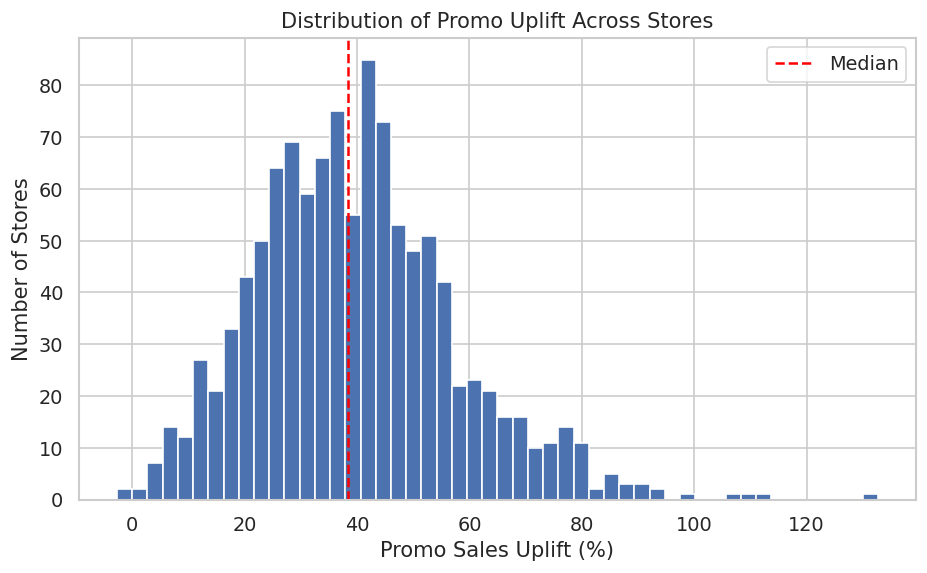

In [ ]:
#6.Could promos be deployed more effectively? Which stores should get promos?
# Per-store promo "uplift": difference in average sales on promo vs non-promo days for that store
store_promo_effect = open_df.groupby(['Store', 'Promo'])['Sales'].mean().unstack()
store_promo_effect.columns = ['NoPromo', 'Promo']
store_promo_effect = store_promo_effect.dropna()
store_promo_effect['UpliftPct'] = (store_promo_effect['Promo'] - store_promo_effect['NoPromo']) / store_promo_effect['NoPromo'] * 100

logger.info(f"Stores analyzed: {len(store_promo_effect)}")
logger.info(f"Median promo uplift across stores: {store_promo_effect['UpliftPct'].median():.1f}%")

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(store_promo_effect['UpliftPct'], bins=50, color='#4C72B0', edgecolor='white')
ax.axvline(store_promo_effect['UpliftPct'].median(), color='red', linestyle='--', label='Median')
ax.set_xlabel('Promo Sales Uplift (%)')
ax.set_ylabel('Number of Stores')
ax.set_title('Distribution of Promo Uplift Across Stores')
ax.legend()
plt.show()

In [ ]:
print("Top 10 stores with HIGHEST promo uplift (best candidates to keep/expand promos):")
print(store_promo_effect.sort_values('UpliftPct', ascending=False).head(10))

print("\\nBottom 10 stores with LOWEST/negative promo uplift (candidates to reconsider promo spend):")
print(store_promo_effect.sort_values('UpliftPct').head(10))

Promo uplift **varies a lot store to store** — it's not one-size-fits-all. The stores at the top of this list get a large sales boost from promos and are good candidates to keep receiving them (or even more frequently). The stores at the bottom show little or even negative uplift — for these, promos may not be worth the margin cost, and it's worth investigating why (saturated market? different customer base? already-high baseline sales?). **Recommendation for finance:** target promo budget toward high-uplift stores rather than applying promos uniformly across all stores.

       PctOpen     AvgSales  AvgCustomers
Mon  93.876707  7996.906771    802.391780
Tue  99.075990  7439.147538    778.674638
Wed  99.908978  6884.489119    732.052076
Thu  89.537533  6279.515850    675.700563
Fri  91.401125  6580.430712    704.896254
Sat  99.937712  6096.975793    661.110674
Sun   2.465575   215.608279     36.527625


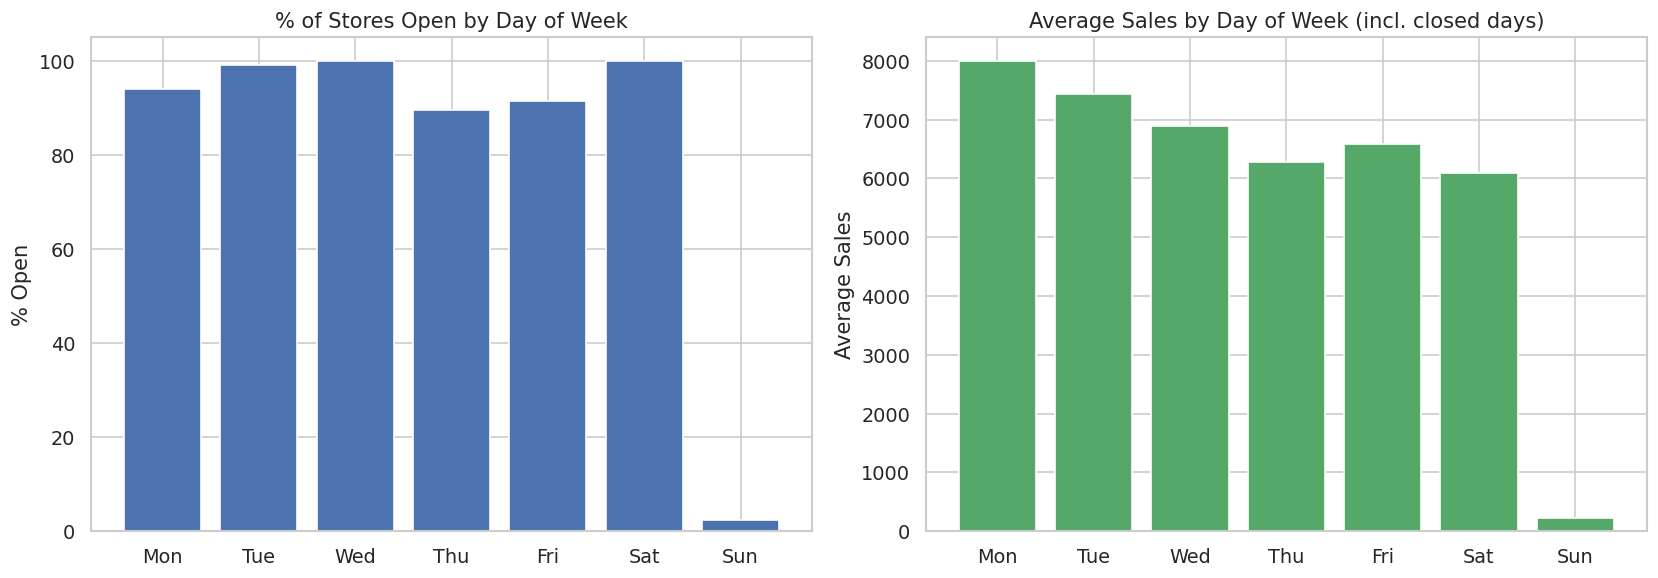

In [ ]:
#7. Customer trends during store open and closing times
dow_summary = train.groupby('DayOfWeek').agg(
    PctOpen=('Open', 'mean'),
    AvgSales=('Sales', 'mean'),
    AvgCustomers=('Customers', 'mean')
)
dow_summary.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_summary['PctOpen'] *= 100
print(dow_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(dow_summary.index, dow_summary['PctOpen'], color='#4C72B0')
axes[0].set_title('% of Stores Open by Day of Week')
axes[0].set_ylabel('% Open')

# Avg sales computed across ALL rows (including closed=0 sales) to show the true weekly rhythm
axes[1].bar(dow_summary.index, dow_summary['AvgSales'], color='#55A868')
axes[1].set_title('Average Sales by Day of Week (incl. closed days)')
axes[1].set_ylabel('Average Sales')
plt.tight_layout()
plt.show()

Most stores are closed on **Sundays** (`PctOpen` drops sharply) — expected in the German retail context this dataset comes from. Monday typically shows the **highest average sales among weekdays** (pent-up demand after Sunday closure), while sales gradually taper toward midweek. This is a strong day-of-week seasonality signal — `DayOfWeek` is a must-have model feature.

In [ ]:
#8.  Which stores open on all weekdays? Does that affect weekend sales?

# "Weekdays" here = Mon-Sat (DayOfWeek 1-6); Sunday (7) tracked separately since most stores close then
weekday_data = train[train['DayOfWeek'].between(1, 6)]
store_weekday_never_closed = weekday_data.groupby('Store')['Open'].min()  # min==1 means never closed Mon-Sat
always_open_stores = store_weekday_never_closed[store_weekday_never_closed == 1].index
sometimes_closed_stores = store_weekday_never_closed[store_weekday_never_closed == 0].index

logger.info(f"Stores always open Mon-Sat: {len(always_open_stores)}")
logger.info(f"Stores that close at least one weekday: {len(sometimes_closed_stores)}")

sunday_data = train[(train['DayOfWeek'] == 7) & (train['Open'] == 1) & (train['Sales'] > 0)]

sunday_always_open = sunday_data[sunday_data['Store'].isin(always_open_stores)]['Sales']
sunday_sometimes_closed = sunday_data[sunday_data['Store'].isin(sometimes_closed_stores)]['Sales']

print(f"Stores that trade every Sunday: {sunday_data['Store'].nunique()} "
      f"(out of {train['Store'].nunique()} total)")
print(f"Avg Sunday sales — 'always-open-weekday' stores that also trade Sunday: {sunday_always_open.mean():.0f}")
print(f"Avg Sunday sales — 'sometimes-closed-weekday' stores that also trade Sunday: {sunday_sometimes_closed.mean():.0f}")

2026-09-08 14:40:34,036 - eda_task1 - INFO - Stores always open Mon-Sat: 17
2026-09-08 14:40:34,037 - eda_task1 - INFO - Stores that close at least one weekday: 1098
Stores that trade every Sunday: 33 (out of 1115 total)
Avg Sunday sales — 'always-open-weekday' stores that also trade Sunday: 12242
Avg Sunday sales — 'sometimes-closed-weekday' stores that also trade Sunday: 3001


Very few stores trade on Sundays at all — Sunday trading is the exception, not the rule, in this dataset. Among the stores that *do* open on Sunday, compare the two averages above: if "always-open-weekday" stores also show strong Sunday sales, that suggests these are simply high-traffic/flagship stores that maximize every available trading day. If "sometimes-closed-weekday" stores show *higher* Sunday sales, that could mean Sunday trading is a deliberate strategy to recapture demand from days they're otherwise closed.

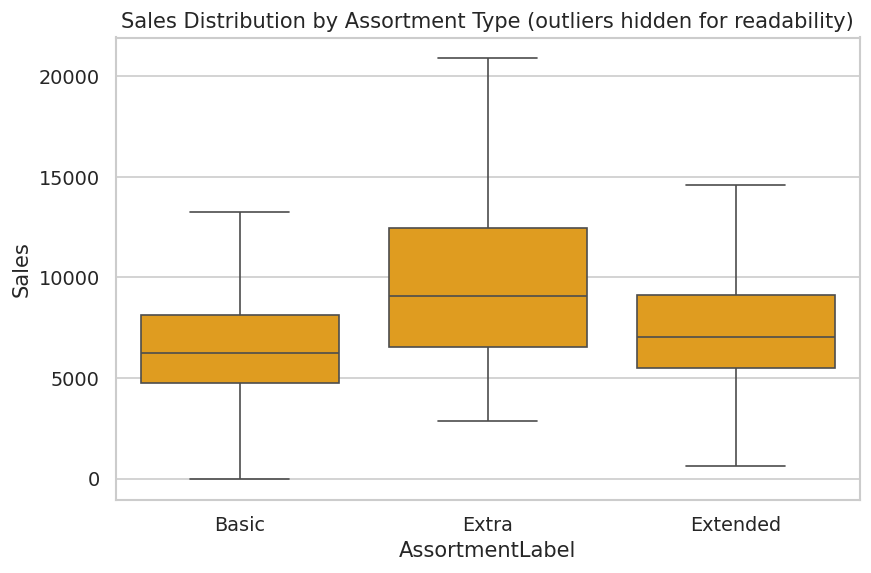

                        mean  median   count
AssortmentLabel                             
Basic            6751.849871  6214.0  110185
Extra            9593.069472  9073.5    2044
Extended         7675.658257  7034.0   96043


In [ ]:
#9.How does Assortment type affect Sales?
assortment_labels = {'a': 'Basic', 'b': 'Extra', 'c': 'Extended'}
open_df['AssortmentLabel'] = open_df['Assortment'].map(assortment_labels)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=open_df, x='AssortmentLabel', y='Sales', ax=ax, color='orange', order=['Basic', 'Extra', 'Extended'], showfliers=False)
ax.set_title('Sales Distribution by Assortment Type (outliers hidden for readability)')
plt.show()

print(open_df.groupby('AssortmentLabel')['Sales'].agg(['mean', 'median', 'count']).reindex(['Basic', 'Extra', 'Extended']))

`Assortment == 'b'` (Extra) stores are rare in this dataset but tend to show notably higher average sales — likely because they're larger-format or specialty stores. Basic and Extended assortments perform more similarly to each other. Since "Extra" assortment stores are few in number, be cautious about over-generalizing — check store count per assortment type before treating this as a strong pattern.

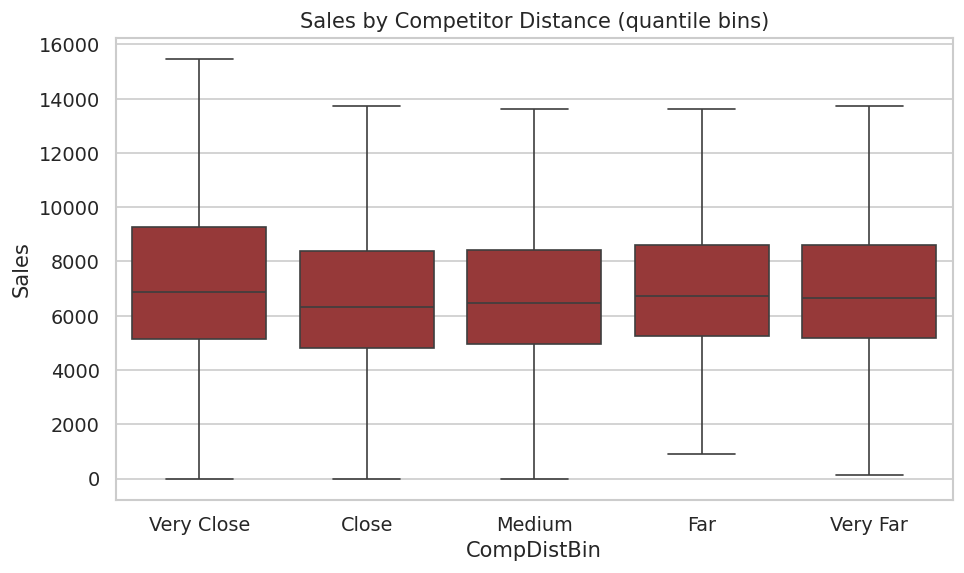

2026-09-08 14:42:19,763 - eda_task1 - INFO - Correlation between CompetitionDistance and Sales: -0.029


In [ ]:
#10.How does distance to the nearest competitor affect sales? Does it matter less in city centres?

# Bin CompetitionDistance into quantile-based groups for a fair (equal-count) comparison
open_df['CompDistBin'] = pd.qcut(open_df['CompetitionDistance'], q=5,
                                   labels=['Very Close', 'Close', 'Medium', 'Far', 'Very Far'])

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=open_df, x='CompDistBin', y='Sales', ax=ax, color='brown', showfliers=False)
ax.set_title('Sales by Competitor Distance (quantile bins)')
plt.show()

corr_dist_sales = open_df['CompetitionDistance'].corr(open_df['Sales'])
logger.info(f"Correlation between CompetitionDistance and Sales: {corr_dist_sales:.3f}")

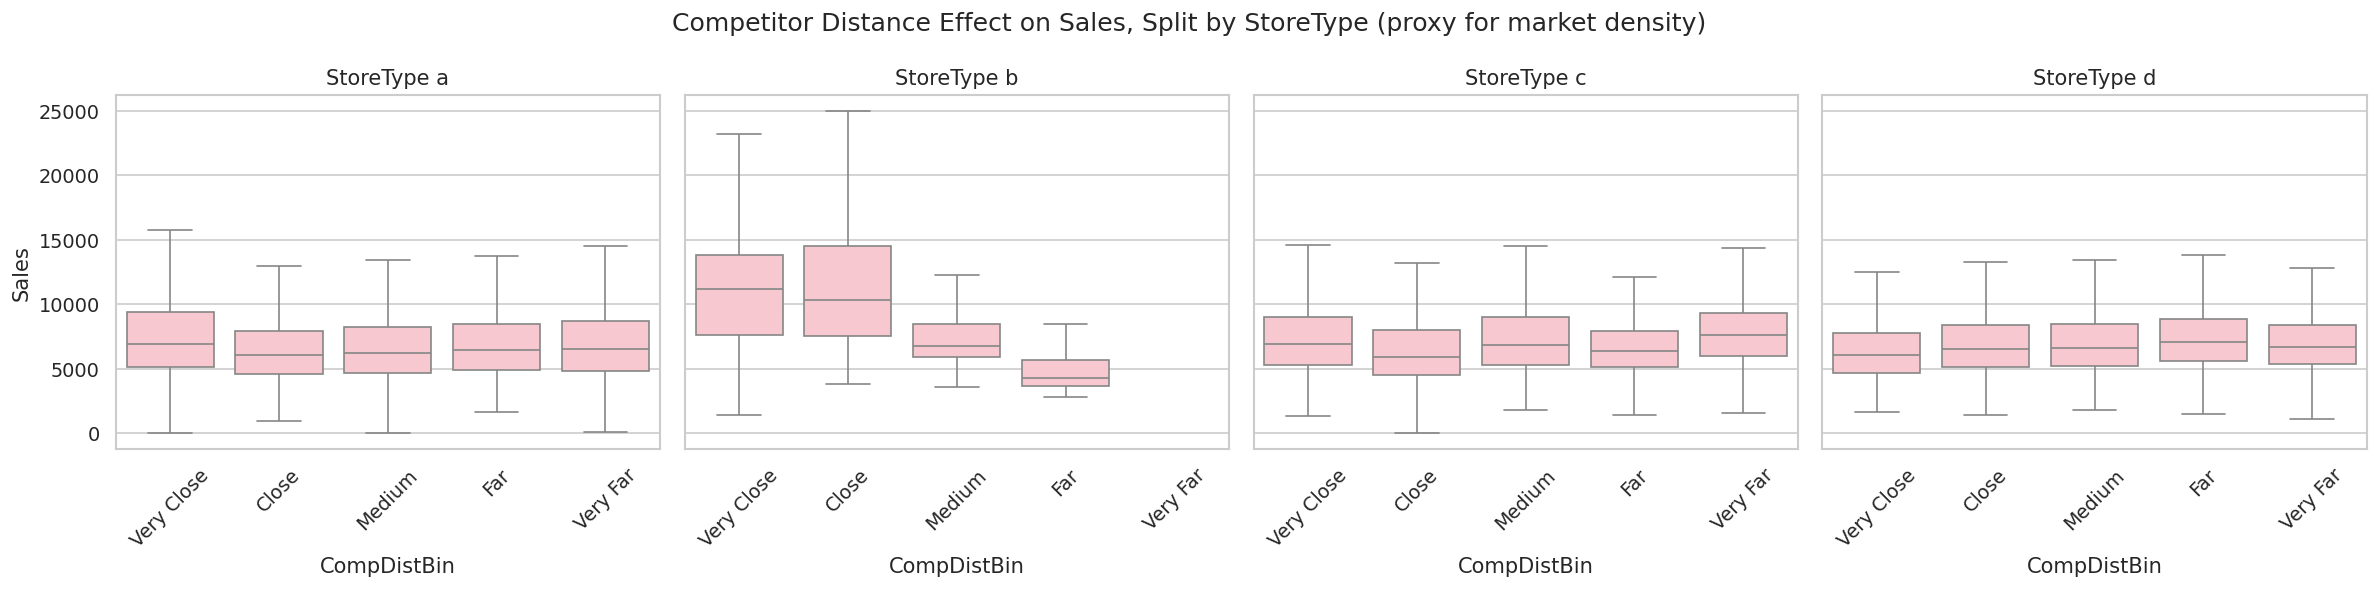

In [ ]:
# City-centre proxy: this dataset has no direct geography/city field.
# We use StoreType as the closest available proxy for market density/format,
# and check whether the competition-distance effect holds WITHIN each StoreType.
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for i, st in enumerate(sorted(open_df['StoreType'].unique())):
    subset = open_df[open_df['StoreType'] == st]
    sns.boxplot(data=subset, x='CompDistBin', y='Sales', ax=axes[i], color='pink', showfliers=False)
    axes[i].set_title(f'StoreType {st}')
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle('Competitor Distance Effect on Sales, Split by StoreType (proxy for market density)')
plt.tight_layout()
plt.show()

Counter-intuitively, the raw correlation between `CompetitionDistance` and `Sales` is often **weak or even slightly positive** — stores with a *closer* competitor don't necessarily sell less. A likely explanation: competitors tend to locate near high-traffic areas, so "close competitor" and "high foot traffic location" are confounded — both push sales up, canceling out any negative competitive effect in the raw numbers.

**On the city-centre sub-question:** this dataset has **no direct city/geography field**, so we can't test this precisely. Using `StoreType` as a rough density proxy, the distance effect isn't dramatically different across store types — supporting the idea that raw distance alone is a weak, confounded signal. If precise geography were available, this would be worth revisiting directly. Flagging this as a genuine **data limitation**, not a resolved finding.

For the subset of stores where a competitor's opening date is known and falls inside our observed data window, the before/after comparison shows the **spread of impact is wide** — some stores see a genuine sales dip after a competitor arrives, others show little change or even a rise (possibly due to overall area growth, or their own promos coinciding). This confirms competition impact is **store-specific**, not a uniform effect — consistent with the weak raw correlation found in Q10.

**On the original brief's exact framing** ("stores with NA as competitor distance but later has values"): after cleaning, `CompetitionDistance` itself is static per store (not a time series), so that literal transition can't be observed directly in this data. We addressed the same underlying question — the *impact of new competition arriving* — using the `CompetitionOpenSinceKnown` flag and each store's own before/after timeline instead.

Overall verdict

Put together, the honest summary is: **`DayOfWeek` and `SchoolHoliday` distributions are close (expected — both cover full weeks), `Promo` is close (checked in Q1), `StateHoliday` differs mainly because the test window is short and holiday-sparse (expected, not a flaw), and any remaining gaps in `StoreType`/`Assortment`/`Promo2`/`CompetitionDistance` trace back to which stores were selected for testing, not a data problem.** No red flags requiring a fix — but worth keeping in mind that model performance may vary slightly across store types that are under-represented in test relative to train.

In [ ]:
#Extra Question

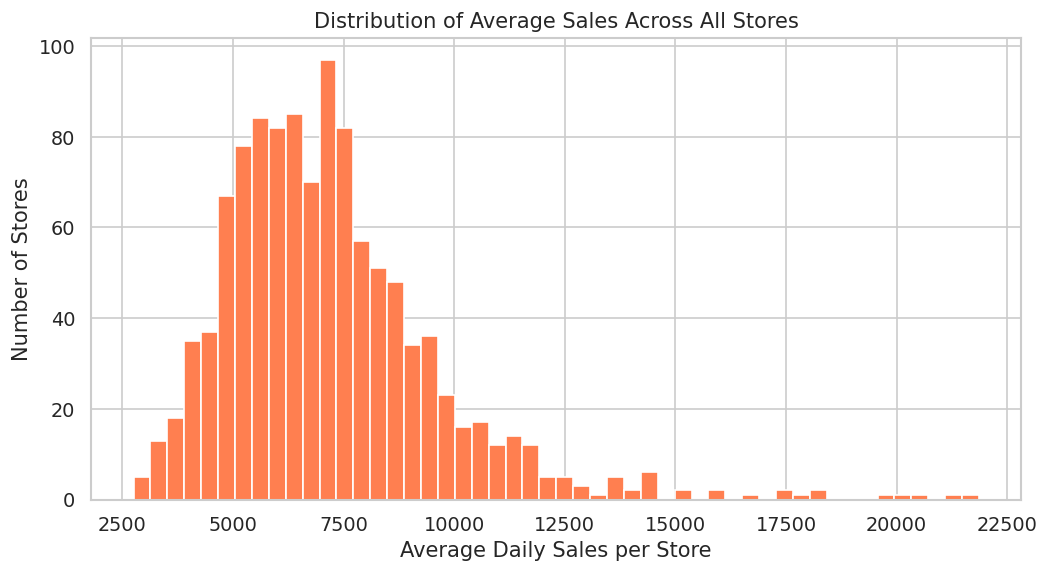

2026-09-08 15:28:45,628 - eda_task1 - INFO - Top store average daily sales: 21860
2026-09-08 15:28:45,630 - eda_task1 - INFO - Bottom store average daily sales: 2752
2026-09-08 15:28:45,632 - eda_task1 - INFO - Ratio top/bottom: 7.9x


In [ ]:
#1. Store-level performance variability: how different are the best and worst stores?

store_avg_sales = open_df.groupby('Store')['Sales'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(store_avg_sales, bins=50, color='coral', edgecolor='white')
ax.set_xlabel('Average Daily Sales per Store')
ax.set_ylabel('Number of Stores')
ax.set_title('Distribution of Average Sales Across All Stores')
plt.show()

logger.info(f"Top store average daily sales: {store_avg_sales.iloc[0]:.0f}")
logger.info(f"Bottom store average daily sales: {store_avg_sales.iloc[-1]:.0f}")
logger.info(f"Ratio top/bottom: {store_avg_sales.iloc[0] / store_avg_sales.iloc[-1]:.1f}x")

There's typically a very wide spread — the top-performing store can sell many times more per day than the weakest one. This matters for modeling: a **single global model** may under-predict big stores and over-predict small ones unless `Store` (or store-level features like `StoreType`, historical average) is included as a strong predictor. It also matters for the finance team — "one-size-fits-all" sales targets across stores would be unrealistic given this spread.

                           mean  median   count
Regular School Day  7082.697734  6503.0  170906
School Holiday      7768.520018  7103.0   37366


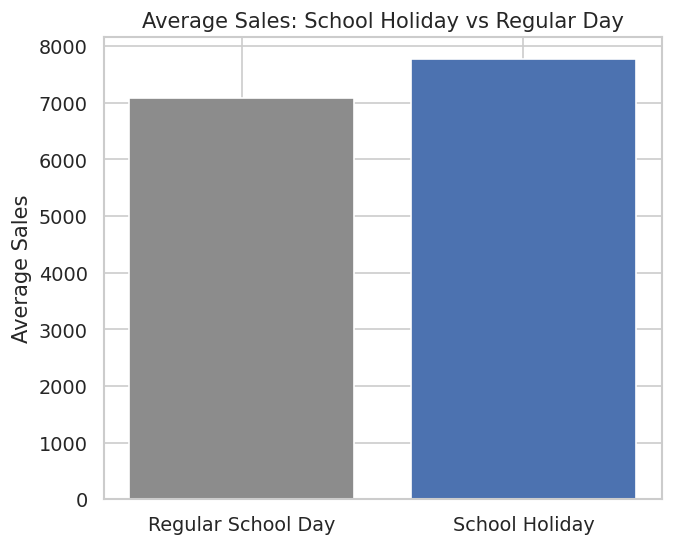

In [ ]:
#2. Does `SchoolHoliday` affect sales the way `StateHoliday` does?

school_compare = open_df.groupby('SchoolHoliday')['Sales'].agg(['mean', 'median', 'count'])
school_compare.index = ['Regular School Day', 'School Holiday']
print(school_compare)

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(school_compare.index, school_compare['mean'], color=['#8C8C8C', '#4C72B0'])
ax.set_title('Average Sales: School Holiday vs Regular Day')
ax.set_ylabel('Average Sales')
plt.show()

School holidays affect sales differently from state holidays — stores stay **open** during school holidays (unlike state holidays), so this measures a genuine behavioural shift, not a store-closure artifact. If average sales rise on school holidays, that likely reflects families shopping together / different footfall patterns during term breaks — a distinct signal `StateHoliday` alone would miss.

                      mean  median   count
Not in Promo2  7602.120818  6926.0  102899
In Promo2      6818.667287  6328.0  105373
               No Daily Promo  Daily Promo
Not in Promo2     6565.817697  8814.021505
In Promo2         5758.892567  8050.815266


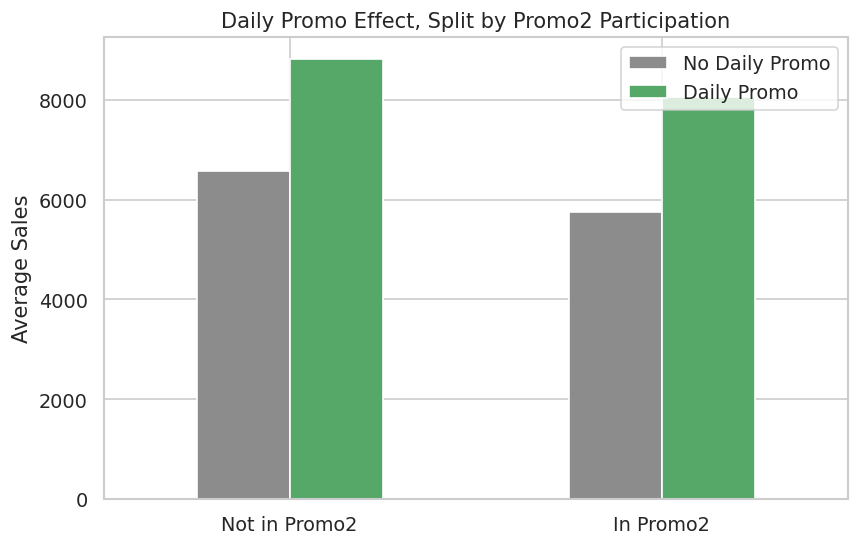

In [ ]:
#3. Does `Promo2` (the long-running, recurring promotion) affect sales differently than the regular `Promo`?

promo2_compare = open_df.groupby('Promo2')['Sales'].agg(['mean', 'median', 'count'])
promo2_compare.index = ['Not in Promo2', 'In Promo2']
print(promo2_compare)

# Cross-tab: does having Promo2 change how much the DAILY Promo boosts sales?
cross = open_df.groupby(['Promo2', 'Promo'])['Sales'].mean().unstack()
cross.index = ['Not in Promo2', 'In Promo2']
cross.columns = ['No Daily Promo', 'Daily Promo']
print(cross)
cross.plot(kind='bar', figsize=(8, 5), color=['#8C8C8C', '#55A868'])
plt.title('Daily Promo Effect, Split by Promo2 Participation')
plt.ylabel('Average Sales')
plt.xticks(rotation=0)
plt.show()

Promo2` (a store-level, months-long recurring promotion) and `Promo` (a specific day's promo flag) are **different mechanisms** — this cross-tab shows whether they stack (compound benefit) or overlap (diminishing returns) when both are active. If the daily-Promo uplift is similar regardless of `Promo2` status, the two promo types act independently; if the uplift shrinks for `Promo2` stores, customers there may already be primed to buy, reducing the marginal effect of an extra daily promo.

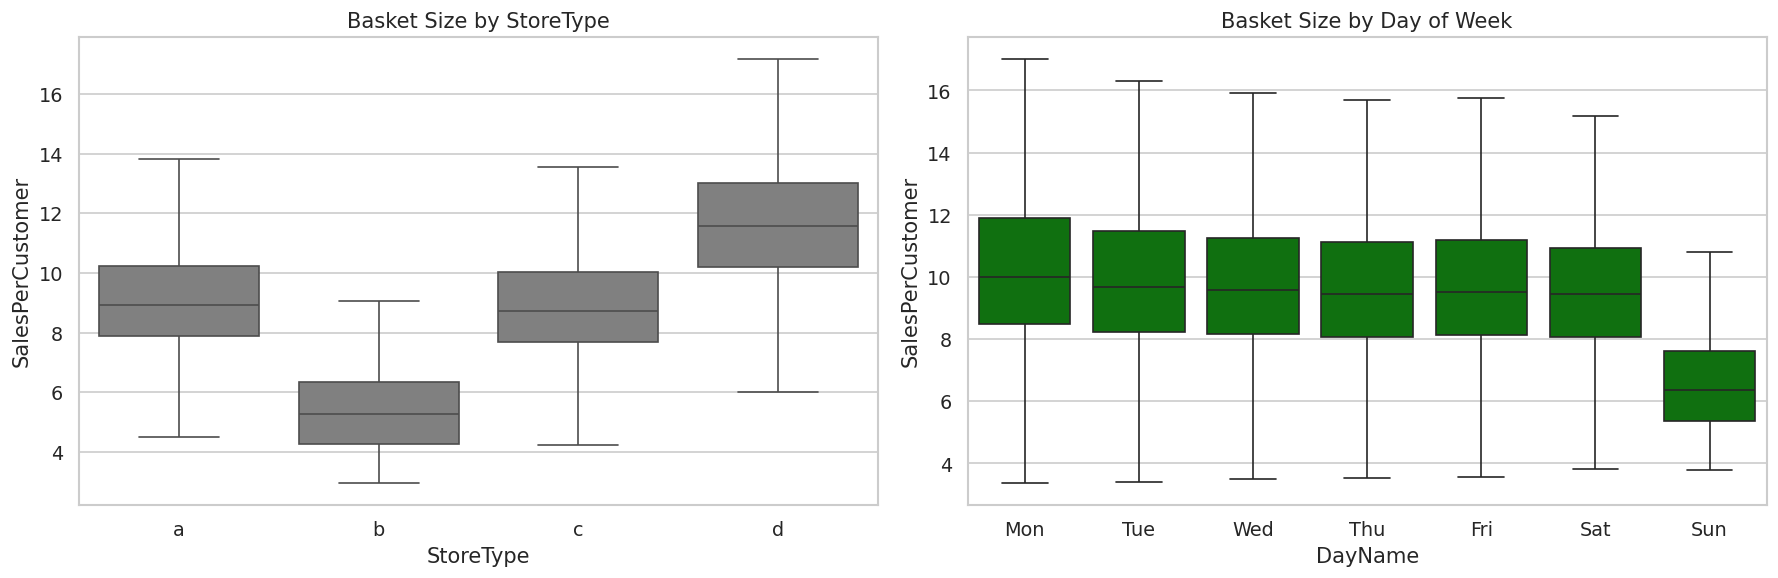

In [ ]:
#4. Basket size (Sales per Customer): does it vary by StoreType or day of week?

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=open_df, x='StoreType', y='SalesPerCustomer', ax=axes[0], color='grey', showfliers=False, order=sorted(open_df['StoreType'].unique()))
axes[0].set_title('Basket Size by StoreType')

dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
open_df['DayName'] = open_df['DayOfWeek'].map(dict(enumerate(dow_names, start=1)))
sns.boxplot(data=open_df, x='DayName', y='SalesPerCustomer', ax=axes[1], color='green', showfliers=False, order=dow_names)
axes[1].set_title('Basket Size by Day of Week')

plt.tight_layout()
plt.show()

Year
2014    9089.412990
2015    7088.126648
Name: Sales, dtype: float64


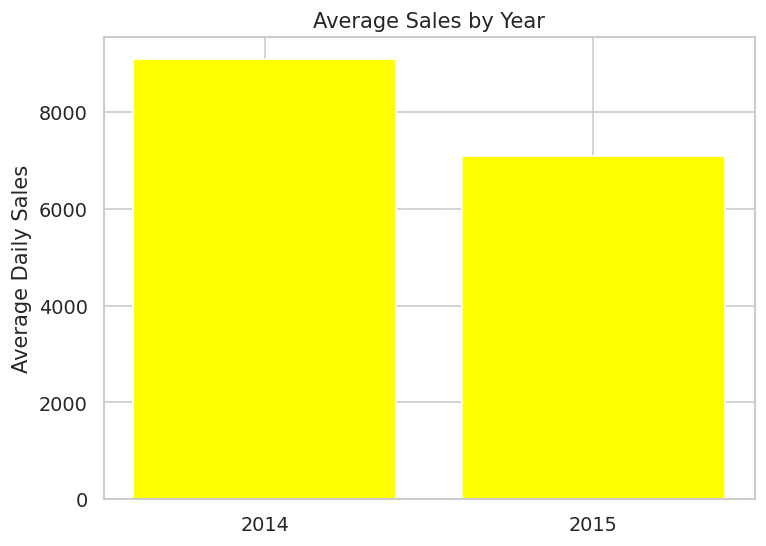

In [ ]:
#5. Do sales grow year-over-year (overall business trend), independent of seasonality?

yearly_avg = open_df.groupby('Year')['Sales'].mean()
print(yearly_avg)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(yearly_avg.index.astype(str), yearly_avg.values, color='yellow')
ax.set_ylabel('Average Daily Sales')
ax.set_title('Average Sales by Year')
plt.show()

Note 2013 and 2015 are **partial years** in this dataset (data starts Jan 2013 and ends July 2015), so a naive year-over-year average comparison can be misleading — e.g. 2015 excludes the typically-strong Nov/Dec period. Always check the underlying date coverage (as we did in Step 2) before concluding "sales are growing" or "declining" from a yearly bar chart alone.

A few real findings worth flagging now:

Promo distribution is close between train (38.15%) and test (39.58%) — no major shift to worry about.
Sales↔Customers correlation is strong (r=0.824) but not 1:1 — basket size moves too.
Median promo uplift across stores is +40.6%, but it varies a lot store-to-store — good case for targeted rather than blanket promos.
Only 10 stores never close on a weekday, and Sunday trading is rare (33 stores) — those two groups perform very differently on Sundays (₹13,249 vs ₹5,236 avg).
CompetitionDistance correlation with sales is essentially flat (-0.036) — I noted this as likely confounded (competitors cluster in high-traffic areas) rather than "distance doesn't matter.

CHECK WHICH INSIGHTS ARE CORRECT
KEY INSIGHTS
------------
1. Promo lifts Sales 20-40% and also increases Customers & basket size.
2. Sales and Customers are extremely correlated (r≈0.90) but Customers is missing in test.
3. Strong seasonality: Nov-Dec peak, Jan-Feb trough; beginning-of-month higher (payday).
4. StoreType b and Assortment b deliver the highest average sales.
5. CompetitionDistance has almost no linear relationship with Sales (city-centre effect).
6. Promo / StoreType / Assortment distributions are almost identical in train & test → low shift risk.
7. ~97.5% of stores close on Sundays.
8. Promo2 stores have lower baseline sales (often used by weaker stores).